## Effective radius

As the REFF_AERO variable showed little growth after Pinatubo, I'll try to see if there is another way to look at it, or if the modes are better to look at seperately.

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal
import seaborn as sns

In [2]:
#path_atm_22 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251125_pinatubo10Tg22_e01/atm/hist"
#ds_22 = xr.open_mfdataset(f"{path_atm_22}/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01.cam.h0.*.nc", combine="by_coords", parallel=True)


In [3]:
#path_atm_19_c =  "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260116_pinatubo10tg_19_c/atm/hist"
#ds_19_c = xr.open_mfdataset(f"{path_atm_19_c}/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02.cam.h0.*.nc", combine="by_coords", parallel=True)

In [4]:
#path_atm_24 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251129_pinatubo17Tg24_e01/atm/hist"
#ds_24 = xr.open_mfdataset(f"{path_atm_24}/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [5]:
#path_atm = "/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
#ds_19 = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.199*.nc", combine="by_coords", parallel=True)

In [6]:
#path_atm_1825 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251204_pinatubo10Tg18_25_e01/atm/hist"
#ds_1825 = xr.open_mfdataset(f"{path_atm_1825}/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [7]:
#path_atm_1825_17tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251207_pinatubo17Tg18_25_e01/atm/hist"
#ds_1825_17tg = xr.open_mfdataset(f"{path_atm_1825_17tg}/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [8]:
#path_atm_1tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251210_pinatubo1Tg19_e01/atm/hist"
#ds_1tg = xr.open_mfdataset(f"{path_atm_1tg}/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [9]:
#path_atm_1pr = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251223_pinatubo10Tg_1pr/atm/hist"
#ds_1pr = xr.open_mfdataset(f"{path_atm_1pr}/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr.cam.h0.*.nc", combine="by_coords", parallel=True)

In [10]:
#path_atm_60tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260108_pinatubo60Tg19_e01/atm/hist"
#ds_60tg = xr.open_mfdataset(f"{path_atm_60tg}/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19.cam.h0.*.nc", combine="by_coords", parallel=True)

In [11]:
#client.close()

In [12]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

"""shifted_time = np.array([shift_one_month_back(t) for t in ds_19['time'].values])
ds_19 = ds_19.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])
ds_22 = ds_22.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])
ds_19_c = ds_19_c.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])
ds_24 = ds_24.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825['time'].values])
ds_1825 = ds_1825.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825_17tg['time'].values])
ds_1825_17tg = ds_1825_17tg.assign_coords(time=shifted_time)"""

"shifted_time = np.array([shift_one_month_back(t) for t in ds_19['time'].values])\nds_19 = ds_19.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])\nds_22 = ds_22.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])\nds_19_c = ds_19_c.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])\nds_24 = ds_24.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_1825['time'].values])\nds_1825 = ds_1825.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_1825_17tg['time'].values])\nds_1825_17tg = ds_1825_17tg.assign_coords(time=shifted_time)"

In [13]:
"""shifted_time = np.array([shift_one_month_back(t) for t in ds_1tg['time'].values])
ds_1tg = ds_1tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1pr['time'].values])
ds_1pr = ds_1pr.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_60tg['time'].values])
ds_60tg = ds_60tg.assign_coords(time=shifted_time)"""

"shifted_time = np.array([shift_one_month_back(t) for t in ds_1tg['time'].values])\nds_1tg = ds_1tg.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_1pr['time'].values])\nds_1pr = ds_1pr.assign_coords(time=shifted_time)\n\nshifted_time = np.array([shift_one_month_back(t) for t in ds_60tg['time'].values])\nds_60tg = ds_60tg.assign_coords(time=shifted_time)"

In [14]:
"""lat_19 = ds_19["lat"]
weighted_lat_19 = np.cos(np.deg2rad(lat_19))
lat_19_c = ds_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))
lat_22 = ds_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat_22))
lat_24 = ds_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat_24))
lat_1825 = ds_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat_1825))
lat_1825_17tg = ds_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat_1825_17tg))
lat_1tg = ds_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat_1tg))
lat_1pr = ds_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat_1pr))
lat_60tg = ds_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat_60tg))"""

'lat_19 = ds_19["lat"]\nweighted_lat_19 = np.cos(np.deg2rad(lat_19))\nlat_19_c = ds_19_c["lat"]\nweighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))\nlat_22 = ds_22["lat"]\nweighted_lat_22 = np.cos(np.deg2rad(lat_22))\nlat_24 = ds_24["lat"]\nweighted_lat_24 = np.cos(np.deg2rad(lat_24))\nlat_1825 = ds_1825["lat"]\nweighted_lat_1825 = np.cos(np.deg2rad(lat_1825))\nlat_1825_17tg = ds_1825_17tg["lat"]\nweighted_lat_1825_17tg = np.cos(np.deg2rad(lat_1825_17tg))\nlat_1tg = ds_1tg["lat"]\nweighted_lat_1tg = np.cos(np.deg2rad(lat_1tg))\nlat_1pr = ds_1pr["lat"]\nweighted_lat_1pr = np.cos(np.deg2rad(lat_1pr))\nlat_60tg = ds_60tg["lat"]\nweighted_lat_60tg = np.cos(np.deg2rad(lat_60tg))'

In [15]:
#ds_19_c["lev"]

In [16]:
"""tropopause_19 = ds_19["TROP_P"].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
p_lev_19 = tropopause_19 * 0.01
tropopause_19_c = ds_19_c["TROP_P"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
p_lev_19_c = tropopause_19_c * 0.01
tropopause_22 = ds_22["TROP_P"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
p_lev_22 = tropopause_22 * 0.01
tropopause_24 = ds_24["TROP_P"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
p_lev_24 = tropopause_24 * 0.01
tropopause_1825 = ds_1825["TROP_P"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
p_lev_1825 = tropopause_1825 * 0.01
tropopause_1825_17tg = ds_1825_17tg["TROP_P"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
p_lev_1825_17tg = tropopause_1825_17tg * 0.01
tropopause_1tg = ds_1tg["TROP_P"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
p_lev_1tg = tropopause_1tg * 0.01
tropopause_1pr = ds_1pr["TROP_P"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
p_lev_1pr = tropopause_1pr * 0.01
tropopause_60tg = ds_60tg["TROP_P"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
p_lev_60tg = tropopause_60tg * 0.01"""

'tropopause_19 = ds_19["TROP_P"].weighted(weighted_lat_19).mean(dim=["lat", "lon"])\np_lev_19 = tropopause_19 * 0.01\ntropopause_19_c = ds_19_c["TROP_P"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])\np_lev_19_c = tropopause_19_c * 0.01\ntropopause_22 = ds_22["TROP_P"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])\np_lev_22 = tropopause_22 * 0.01\ntropopause_24 = ds_24["TROP_P"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])\np_lev_24 = tropopause_24 * 0.01\ntropopause_1825 = ds_1825["TROP_P"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])\np_lev_1825 = tropopause_1825 * 0.01\ntropopause_1825_17tg = ds_1825_17tg["TROP_P"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])\np_lev_1825_17tg = tropopause_1825_17tg * 0.01\ntropopause_1tg = ds_1tg["TROP_P"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])\np_lev_1tg = tropopause_1tg * 0.01\ntropopause_1pr = ds_1pr["TROP_P"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])\np_lev_1pr = tropopause_1pr * 0.01

In [17]:
reff_data_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/REFF_AERO_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in reff_data_19['time'].values])
reff_data_19 = reff_data_19.assign_coords(time=shifted_time_19)
reff_data_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/REFF_AERO_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in reff_data_19_c['time'].values])
reff_data_19_c = reff_data_19_c.assign_coords(time=shifted_time_19_c)
reff_data_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/REFF_AERO_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in reff_data_22['time'].values])
reff_data_22 = reff_data_22.assign_coords(time=shifted_time_22)
reff_data_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/REFF_AERO_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in reff_data_24['time'].values])
reff_data_24 = reff_data_24.assign_coords(time=shifted_time_24)
reff_data_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/REFF_AERO_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in reff_data_1825_17tg['time'].values])
reff_data_1825_17tg = reff_data_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
reff_data_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/REFF_AERO_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in reff_data_1825['time'].values])
reff_data_1825 = reff_data_1825.assign_coords(time=shifted_time_1825)
reff_data_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/REFF_AERO_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in reff_data_1tg['time'].values])
reff_data_1tg = reff_data_1tg.assign_coords(time=shifted_time_1tg)
reff_data_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/REFF_AERO_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in reff_data_1pr['time'].values])
reff_data_1pr = reff_data_1pr.assign_coords(time=shifted_time_1pr)
reff_data_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/REFF_AERO_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in reff_data_60tg['time'].values])
reff_data_60tg = reff_data_60tg.assign_coords(time=shifted_time_60tg)

In [18]:
lat = reff_data_19["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
lat = reff_data_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat))
lat = reff_data_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat))
lat = reff_data_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat))
lat = reff_data_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat))
lat = reff_data_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat))
lat = reff_data_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat))
lat = reff_data_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat))
lat = reff_data_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat))

In [19]:
trop_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/TROP_P_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in trop_19['time'].values])
trop_19 = trop_19.assign_coords(time=shifted_time_19)
trop_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/TROP_P_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in trop_19_c['time'].values])
trop_19_c = trop_19_c.assign_coords(time=shifted_time_19_c)
trop_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/TROP_P_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in trop_22['time'].values])
trop_22 = trop_22.assign_coords(time=shifted_time_22)
trop_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/TROP_P_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in trop_24['time'].values])
trop_24 = trop_24.assign_coords(time=shifted_time_24)
trop_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/TROP_P_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in trop_1825_17tg['time'].values])
trop_1825_17tg = trop_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
trop_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/TROP_P_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in trop_1825['time'].values])
trop_1825 = trop_1825.assign_coords(time=shifted_time_1825)
trop_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/TROP_P_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in trop_1tg['time'].values])
trop_1tg = trop_1tg.assign_coords(time=shifted_time_1tg)
trop_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/TROP_P_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in trop_1pr['time'].values])
trop_1pr = trop_1pr.assign_coords(time=shifted_time_1pr)
trop_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/TROP_P_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in trop_60tg['time'].values])
trop_60tg = trop_60tg.assign_coords(time=shifted_time_60tg)

In [20]:
tropopause = trop_19["TROP_P"].weighted(weighted_lat).mean(dim=["lat", "lon"])
tropopause_22 = trop_22["TROP_P"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
tropopause_19_c = trop_19_c["TROP_P"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
tropopause_24 = trop_24["TROP_P"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
tropopause_1825 = trop_1825["TROP_P"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
tropopause_1825_17tg = trop_1825_17tg["TROP_P"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
tropopause_1tg = trop_1tg["TROP_P"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
tropopause_1pr= trop_1pr["TROP_P"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
tropopause_60tg= trop_60tg["TROP_P"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])

In [21]:
tropopause_trop = trop_19["TROP_P"].sel(lat=slice(-20,20)).weighted(weighted_lat).mean(dim=["lat", "lon"])
tropopause_22_trop = trop_22["TROP_P"].sel(lat=slice(-20,20)).weighted(weighted_lat_22).mean(dim=["lat", "lon"])
tropopause_19_c_trop = trop_19_c["TROP_P"].sel(lat=slice(-20,20)).weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
tropopause_24_trop = trop_24["TROP_P"].sel(lat=slice(-20,20)).weighted(weighted_lat_24).mean(dim=["lat", "lon"])
tropopause_1825_trop = trop_1825["TROP_P"].sel(lat=slice(-20,20)).weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
tropopause_1825_17tg_trop = trop_1825_17tg["TROP_P"].sel(lat=slice(-20,20)).weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
tropopause_1tg_trop = trop_1tg["TROP_P"].sel(lat=slice(-20,20)).weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
tropopause_1pr_trop= trop_1pr["TROP_P"].sel(lat=slice(-20,20)).weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
tropopause_60tg_trop= trop_60tg["TROP_P"].sel(lat=slice(-20,20)).weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])

In [22]:
p_lev = tropopause * 0.01
p_lev_22 = tropopause_22 * 0.01
p_lev_19_c = tropopause_19_c * 0.01
p_lev_24 = tropopause_24 * 0.01
p_lev_1825 = tropopause_1825 * 0.01
p_lev_1825_17tg = tropopause_1825_17tg * 0.01
p_lev_1tg = tropopause_1tg * 0.01
p_lev_1pr = tropopause_1pr * 0.01
p_lev_60tg = tropopause_60tg * 0.01

In [23]:
p_lev_trop = tropopause_trop * 0.01
p_lev_22_trop = tropopause_22_trop * 0.01
p_lev_19_c_trop = tropopause_19_c_trop * 0.01
p_lev_24_trop = tropopause_24_trop * 0.01
p_lev_1825_trop = tropopause_1825_trop * 0.01
p_lev_1825_17tg_trop = tropopause_1825_17tg_trop * 0.01
p_lev_1tg_trop = tropopause_1tg_trop * 0.01
p_lev_1pr_trop = tropopause_1pr_trop * 0.01
p_lev_60tg_trop = tropopause_60tg_trop * 0.01

In [24]:
"""tropopause_19_trop = ds_19["TROP_P"].weighted(weighted_lat_19).sel(lat = slice(-20,20)).mean(dim=["lat", "lon"])
p_lev_19_trop = tropopause_19_trop * 0.01
tropopause_19_c_trop = ds_19_c["TROP_P"].weighted(weighted_lat_19_c).sel(lat = slice(-20,20)).mean(dim=["lat", "lon"])
p_lev_19_c_trop = tropopause_19_c_trop * 0.01
tropopause_22_trop = ds_22["TROP_P"].weighted(weighted_lat_22).sel(lat = slice(-20,20)).mean(dim=["lat", "lon"])
p_lev_22_trop = tropopause_22_trop * 0.01
tropopause_24_trop = ds_24["TROP_P"].weighted(weighted_lat_24).sel(lat = slice(-20,20)).mean(dim=["lat", "lon"])
p_lev_24_trop = tropopause_24_trop * 0.01
tropopause_1825_trop = ds_1825["TROP_P"].weighted(weighted_lat_1825).sel(lat = slice(-20,20)).mean(dim=["lat", "lon"])
p_lev_1825_trop = tropopause_1825_trop * 0.01
tropopause_1825_17tg_trop = ds_1825_17tg["TROP_P"].weighted(weighted_lat_1825_17tg).sel(lat = slice(-20,20)).mean(dim=["lat", "lon"])
p_lev_1825_17tg_trop = tropopause_1825_17tg_trop * 0.01
tropopause_1tg_trop = ds_1tg["TROP_P"].weighted(weighted_lat_1tg).sel(lat = slice(-20,20)).mean(dim=["lat", "lon"])
p_lev_1tg_trop = tropopause_1tg_trop * 0.01
tropopause_1pr_trop = ds_1pr["TROP_P"].weighted(weighted_lat_1pr).sel(lat = slice(-20,20)).mean(dim=["lat", "lon"])
p_lev_1pr_trop = tropopause_1pr_trop * 0.01
tropopause_60tg_trop = ds_60tg["TROP_P"].weighted(weighted_lat_60tg).sel(lat = slice(-20,20)).mean(dim=["lat", "lon"])
p_lev_60tg_trop = tropopause_60tg_trop * 0.01"""

'tropopause_19_trop = ds_19["TROP_P"].weighted(weighted_lat_19).sel(lat = slice(-20,20)).mean(dim=["lat", "lon"])\np_lev_19_trop = tropopause_19_trop * 0.01\ntropopause_19_c_trop = ds_19_c["TROP_P"].weighted(weighted_lat_19_c).sel(lat = slice(-20,20)).mean(dim=["lat", "lon"])\np_lev_19_c_trop = tropopause_19_c_trop * 0.01\ntropopause_22_trop = ds_22["TROP_P"].weighted(weighted_lat_22).sel(lat = slice(-20,20)).mean(dim=["lat", "lon"])\np_lev_22_trop = tropopause_22_trop * 0.01\ntropopause_24_trop = ds_24["TROP_P"].weighted(weighted_lat_24).sel(lat = slice(-20,20)).mean(dim=["lat", "lon"])\np_lev_24_trop = tropopause_24_trop * 0.01\ntropopause_1825_trop = ds_1825["TROP_P"].weighted(weighted_lat_1825).sel(lat = slice(-20,20)).mean(dim=["lat", "lon"])\np_lev_1825_trop = tropopause_1825_trop * 0.01\ntropopause_1825_17tg_trop = ds_1825_17tg["TROP_P"].weighted(weighted_lat_1825_17tg).sel(lat = slice(-20,20)).mean(dim=["lat", "lon"])\np_lev_1825_17tg_trop = tropopause_1825_17tg_trop * 0.01\ntr

In [25]:
"""def compute_SReff(ds, p_lev=None, p_lev_upper=None, p_lev_lower=None,
                  lat_range=None, lon_range=None,
                  weighted_lat=None, weighted_lev=None,
                  cm_to_mym=10000):
    
    da = ds["REFF_AERO"]
    
    if p_lev is not None:
        da = da.sel(lev = p_lev, method="nearest")
    elif p_lev_upper is not None and p_lev_lower is not None:
        da = da.where((da["lev"] >= p_lev_upper) & (da["lev"] <= p_lev_lower))
    elif p_lev_lower is not None:
        da = da.where(da["lev"] <= p_lev_lower)
    
    if lat_range:
        da = da.sel(lat=slice(*lat_range))
    if lon_range:
        da = da.sel(lon=slice(*lon_range))
    
    da = da.weighted(weighted_lat).mean(dim=["lat","lon"]) * cm_to_mym
    da = da.weighted(weighted_lev).mean(dim="lev")
    
    return da"""


'def compute_SReff(ds, p_lev=None, p_lev_upper=None, p_lev_lower=None,\n                  lat_range=None, lon_range=None,\n                  weighted_lat=None, weighted_lev=None,\n                  cm_to_mym=10000):\n\n    da = ds["REFF_AERO"]\n\n    if p_lev is not None:\n        da = da.sel(lev = p_lev, method="nearest")\n    elif p_lev_upper is not None and p_lev_lower is not None:\n        da = da.where((da["lev"] >= p_lev_upper) & (da["lev"] <= p_lev_lower))\n    elif p_lev_lower is not None:\n        da = da.where(da["lev"] <= p_lev_lower)\n\n    if lat_range:\n        da = da.sel(lat=slice(*lat_range))\n    if lon_range:\n        da = da.sel(lon=slice(*lon_range))\n\n    da = da.weighted(weighted_lat).mean(dim=["lat","lon"]) * cm_to_mym\n    da = da.weighted(weighted_lev).mean(dim="lev")\n\n    return da'

In [26]:
da_2d = reff_data_19["REFF_AERO"].sel(lat=slice(-20, 20)).mean(dim=["lat", "lon"])

mask = np.zeros(da_2d.shape, dtype=bool)
for t in range(da_2d.shape[0]):
    limit = p_lev.values[t]
    mask[t, :] = (da_2d.lev >= 3.64) & (da_2d.lev <= limit)

da_strat = da_2d.where(mask)
SReff_simple = da_strat.mean(dim="lev", skipna=True) * 10000

lev_diff = np.gradient(da_2d.lev.values)
weights = xr.DataArray(lev_diff, coords={'lev': da_2d.lev}, dims=['lev'])

numerator = (da_strat * weights).sum(dim="lev", skipna=True)
denominator = weights.where(~np.isnan(da_strat)).sum(dim="lev", skipna=True)
SReff_weighted = (numerator / denominator) * 10000

print("Simple mean (first 5):", SReff_simple.values[:5])
print("Weighted mean (first 5):", SReff_weighted.values[:5])

Simple mean (first 5): [0.11289872 0.11376099 0.11546011 0.11690031 0.12053116]
Weighted mean (first 5): [0.11524414 0.11601467 0.11809861 0.11948736 0.12493431]


In [27]:
def compute_SReff_hybrid(ds, p_lev_lower, lat_range=None, lon_range=None, p_lev_upper=3.643466):
    temp_ds = ds.sel(lat=slice(*lat_range)) if lat_range else ds
    if lon_range and 'lon' in temp_ds.dims:
        temp_ds = temp_ds.sel(lon=slice(*lon_range))
    
    da_reff = temp_ds["REFF_AERO"]

    if isinstance(p_lev_lower, (int, float)):
        p_low_ts = p_lev_lower
    else:
        t_p = p_lev_lower
        if lat_range and 'lat' in t_p.dims:
            t_p = t_p.sel(lat=slice(*lat_range))
        if lon_range and 'lon' in t_p.dims:
            t_p = t_p.sel(lon=slice(*lon_range))
            
        dims_to_mean = [d for d in t_p.dims if d != 'time']
        if dims_to_mean:
            weights_p = np.cos(np.deg2rad(temp_ds.lat)) 
            p_low_ts = t_p.weighted(weights_p).mean(dim=dims_to_mean)
        else:
            p_low_ts = t_p

    weights_lat = np.cos(np.deg2rad(temp_ds.lat))
    d_dims = [d for d in ['lat', 'lon'] if d in da_reff.dims]
    da_2d = da_reff.weighted(weights_lat).mean(dim=d_dims)
    
    mask = xr.DataArray(False, coords=da_2d.coords, dims=da_2d.dims)
    for t in range(len(da_2d.time)):
        if isinstance(p_low_ts, (int, float)):
            limit = p_low_ts
        else:
            limit = float(p_low_ts.isel(time=t).values)
            
        mask[t, :] = (da_2d.lev >= p_lev_upper) & (da_2d.lev <= limit)
    
    da_strat = da_2d.where(mask)
    lev_diff = np.abs(np.gradient(da_2d.lev.values))
    weights_lev = xr.DataArray(lev_diff, coords={'lev': da_2d.lev}, dims=['lev'])
    
    num = (da_strat * weights_lev).sum(dim="lev", skipna=True)
    den = weights_lev.where(da_strat.notnull()).sum(dim="lev", skipna=True)
    
    return (num / den) * 10000

In [28]:
SReff = compute_SReff_hybrid(reff_data_19, p_lev_upper=3.643466, p_lev_lower = p_lev)
SReff = SReff.sel(time=slice("1991-01-01", "1996-01-01"))
SReff_19_c = compute_SReff_hybrid(reff_data_19_c, p_lev_upper=3.643466, p_lev_lower = p_lev_19_c)
SReff_22 = compute_SReff_hybrid(reff_data_22, p_lev_upper=3.643466, p_lev_lower=p_lev_22)
SReff_24 = compute_SReff_hybrid(reff_data_24, p_lev_upper=3.643466, p_lev_lower=p_lev_24)
SReff_1825 = compute_SReff_hybrid(reff_data_1825, p_lev_upper=3.643466, p_lev_lower=p_lev_1825)
SReff_1825_17tg = compute_SReff_hybrid(reff_data_1825_17tg, p_lev_upper=3.643466, p_lev_lower=p_lev_1825_17tg)
SReff_1tg = compute_SReff_hybrid(reff_data_1tg, p_lev_upper=3.643466, p_lev_lower=p_lev_1tg)
SReff_1pr = compute_SReff_hybrid(reff_data_1pr, p_lev_upper=3.643466, p_lev_lower=p_lev_1pr)
SReff_60tg = compute_SReff_hybrid(reff_data_60tg,p_lev_upper=3.643466,  p_lev_lower=p_lev_60tg)

<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1205441/1858709640.py:24: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Effective radius [$\mu$m]")


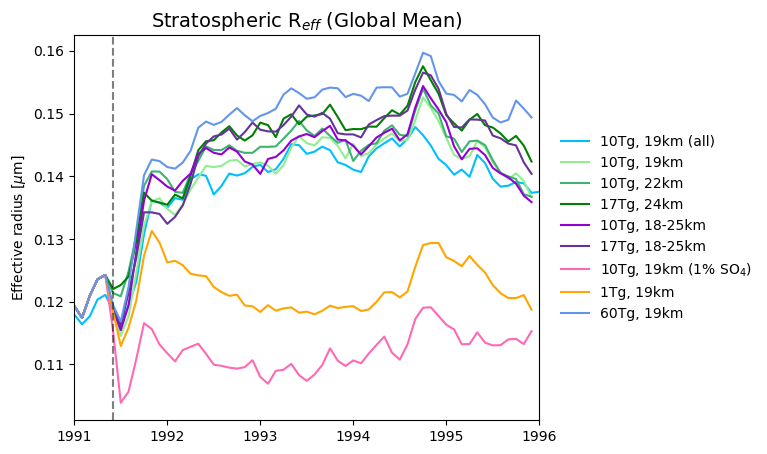

In [29]:
def to_float(x):
    return [t.year + (t.month-1)/12 for t in x.time.values]

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(to_float(SReff), SReff, color="deepskyblue", label="10Tg, 19km (all)")
ax.plot(to_float(SReff_19_c), SReff_19_c, color="lightgreen", label="10Tg, 19km")
ax.plot(to_float(SReff_22), SReff_22, color="mediumseagreen", label="10Tg, 22km")
ax.plot(to_float(SReff_24), SReff_24, color="green", label="17Tg, 24km") 
ax.plot(to_float(SReff_1825), SReff_1825, color="darkviolet", label="10Tg, 18-25km")
ax.plot(to_float(SReff_1825_17tg), SReff_1825_17tg, color="rebeccapurple", label="17Tg, 18-25km")
ax.plot(to_float(SReff_1pr), SReff_1pr, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax.plot(to_float(SReff_1tg), SReff_1tg, color="orange", label="1Tg, 19km")
ax.plot(to_float(SReff_60tg), SReff_60tg, color="cornflowerblue", label="60Tg, 19km")

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12   

ax.axvline(eruption_float, color='black', ls="--", alpha=0.5)
ax.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
ax.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
ax.set_xlim(1991, 1996)

ax.set_ylabel("Effective radius [$\mu$m]")
ax.set_title("Stratospheric R$_{eff}$ (Global Mean)", fontsize=14)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

plt.show()

In [30]:
SReff_trop = compute_SReff_hybrid(reff_data_19, p_lev_upper=3.643466, p_lev_lower = p_lev_trop, lat_range=(-20,20))
SReff_trop = SReff_trop.sel(time=slice("1991-01-01", "1996-01-01"))
SReff_19_c_trop = compute_SReff_hybrid(reff_data_19_c, p_lev_upper=3.643466, p_lev_lower = p_lev_19_c_trop,lat_range=(-20,20))
SReff_22_trop = compute_SReff_hybrid(reff_data_22, p_lev_upper=3.643466,p_lev_lower=p_lev_22_trop, lat_range=(-20,20))
SReff_24_trop = compute_SReff_hybrid(reff_data_24, p_lev_upper=3.643466,p_lev_lower=p_lev_24_trop, lat_range=(-20,20))
SReff_1825_trop = compute_SReff_hybrid(reff_data_1825, p_lev_upper=3.643466,p_lev_lower=p_lev_1825_trop, lat_range=(-20,20))
SReff_1825_17tg_trop = compute_SReff_hybrid(reff_data_1825_17tg, p_lev_upper=3.643466,p_lev_lower=p_lev_1825_17tg_trop, lat_range=(-20,20))
SReff_1tg_trop = compute_SReff_hybrid(reff_data_1tg, p_lev_upper=3.643466,p_lev_lower=p_lev_1tg_trop, lat_range=(-20,20))
SReff_1pr_trop = compute_SReff_hybrid(reff_data_1pr, p_lev_upper=3.643466,p_lev_lower=p_lev_1pr_trop, lat_range=(-20,20))
SReff_60tg_trop = compute_SReff_hybrid(reff_data_60tg, p_lev_upper=3.643466,p_lev_lower=p_lev_60tg_trop, lat_range=(-20,20))

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1205441/3057147024.py:11: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_ylabel("Effective radius [$\mu$m]")
/tmp/ipykernel_1205441/3057147024.py:23: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_ylabel("Effective radius [$\mu$m]")


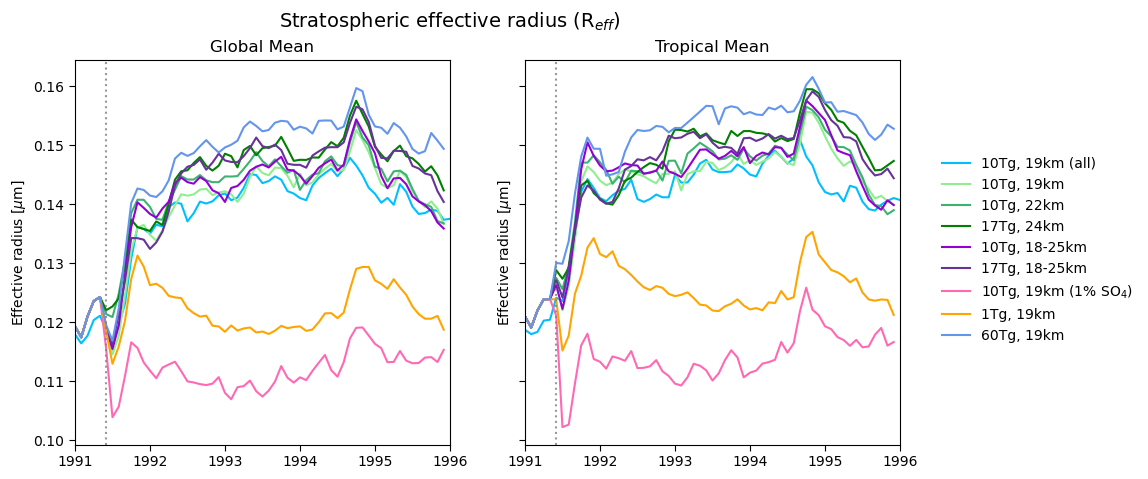

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(to_float(SReff), SReff, color="deepskyblue", label="10Tg, 19km (all)")
ax[0].plot(to_float(SReff_19_c), SReff_19_c, color="lightgreen", label="10Tg, 19km")
ax[0].plot(to_float(SReff_22), SReff_22, color="mediumseagreen", label="10Tg, 22km")
ax[0].plot(to_float(SReff_24), SReff_24, color="green", label="17Tg, 24km") 
ax[0].plot(to_float(SReff_1825), SReff_1825, color="darkviolet", label="10Tg, 18-25km")
ax[0].plot(to_float(SReff_1825_17tg), SReff_1825_17tg, color="rebeccapurple", label="17Tg, 18-25km")
ax[0].plot(to_float(SReff_1pr), SReff_1pr, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[0].plot(to_float(SReff_1tg), SReff_1tg, color="orange", label="1Tg, 19km")
ax[0].plot(to_float(SReff_60tg), SReff_60tg, color="cornflowerblue", label="60Tg, 19km")
ax[0].set_ylabel("Effective radius [$\mu$m]")
ax[0].set_title("Global Mean", fontsize=12)

ax[1].plot(to_float(SReff_trop), SReff_trop, color="deepskyblue", label="10Tg, 19km (all)")
ax[1].plot(to_float(SReff_19_c_trop), SReff_19_c_trop, color="lightgreen", label="10Tg, 19km")
ax[1].plot(to_float(SReff_22_trop), SReff_22_trop, color="mediumseagreen", label="10Tg, 22km")
ax[1].plot(to_float(SReff_24_trop), SReff_24_trop, color="green", label="17Tg, 24km") 
ax[1].plot(to_float(SReff_1825_trop), SReff_1825_trop, color="darkviolet", label="10Tg, 18-25km")
ax[1].plot(to_float(SReff_1825_17tg_trop), SReff_1825_17tg_trop, color="rebeccapurple", label="17Tg, 18-25km")
ax[1].plot(to_float(SReff_1pr_trop), SReff_1pr_trop, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[1].plot(to_float(SReff_1tg_trop), SReff_1tg_trop, color="orange", label="1Tg, 19km")
ax[1].plot(to_float(SReff_60tg_trop), SReff_60tg_trop, color="cornflowerblue", label="60Tg, 19km")
ax[1].set_ylabel("Effective radius [$\mu$m]")
ax[1].set_title("Tropical Mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12   

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)


handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Stratospheric effective radius (R$_{eff}$)", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

In [32]:
SReff_trop_obs = compute_SReff_hybrid(reff_data_19, p_lev_upper=20, p_lev_lower = 50, lat_range=(-20,20))
SReff_trop_obs = SReff_trop_obs.sel(time=slice("1991-01-01", "1996-01-01"))
SReff_19_c_trop_obs = compute_SReff_hybrid(reff_data_19_c, p_lev_upper=20, p_lev_lower = 50, lat_range=(-20,20))
SReff_22_trop_obs = compute_SReff_hybrid(reff_data_22, p_lev_upper=20, p_lev_lower = 50, lat_range=(-20,20))
SReff_24_trop_obs = compute_SReff_hybrid(reff_data_24, p_lev_upper=20, p_lev_lower = 50, lat_range=(-20,20))
SReff_1825_trop_obs = compute_SReff_hybrid(reff_data_1825, p_lev_upper=20, p_lev_lower = 50, lat_range=(-20,20))
SReff_1825_17tg_trop_obs = compute_SReff_hybrid(reff_data_1825_17tg, p_lev_upper=20, p_lev_lower = 50, lat_range=(-20,20))
SReff_1tg_trop_obs = compute_SReff_hybrid(reff_data_1tg, p_lev_upper=20, p_lev_lower = 50, lat_range=(-20,20))
SReff_1pr_trop_obs = compute_SReff_hybrid(reff_data_1pr, p_lev_upper=20, p_lev_lower = 50, lat_range=(-20,20))
SReff_60tg_trop_obs = compute_SReff_hybrid(reff_data_60tg, p_lev_upper=20, p_lev_lower = 50, lat_range=(-20,20))

In [33]:
plev = 64
p_lev_l = 50
p_lev_u = 20
SReff_eq = compute_SReff_hybrid(reff_data_19, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(-5,5))
SReff_eq = SReff_eq.sel(time=slice("1991-01-01", "1996-01-01"))
SReff_19_c_eq = compute_SReff_hybrid(reff_data_19_c, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(-5,5))
SReff_22_eq = compute_SReff_hybrid(reff_data_22, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(-5,5))
SReff_24_eq = compute_SReff_hybrid(reff_data_24, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l,  lat_range=(-5,5))
SReff_1825_eq = compute_SReff_hybrid(reff_data_1825, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(-5,5))
SReff_1825_17tg_eq = compute_SReff_hybrid(reff_data_1825_17tg, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(-5,5))
SReff_1tg_eq = compute_SReff_hybrid(reff_data_1tg, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(-5,5))
SReff_1pr_eq = compute_SReff_hybrid(reff_data_1pr, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l,  lat_range=(-5,5))
SReff_60tg_eq = compute_SReff_hybrid(reff_data_60tg, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(-5,5))


<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1205441/3815965811.py:31: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("$\mu$m")
/tmp/ipykernel_1205441/3815965811.py:32: SyntaxWarning: invalid escape sequence '\c'
  ax.set_title("Stratospheric R$_{eff}$ (Equator: 5$^\circ$S-5$^\circ$N)")


Text(0.5, 1.0, 'Stratospheric R$_{eff}$ (Equator: 5$^\\circ$S-5$^\\circ$N)')

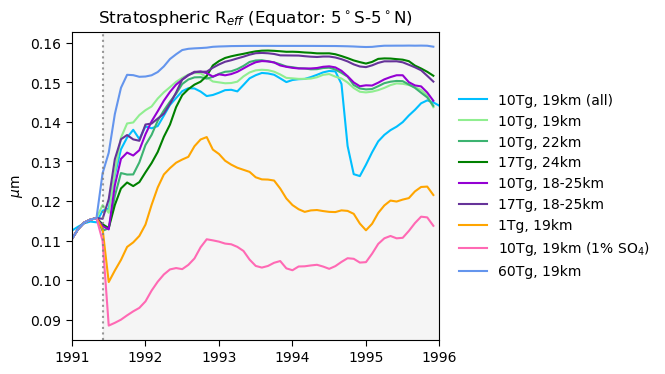

In [34]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(to_float(SReff_eq), SReff_eq, color="deepskyblue", label="10Tg, 19km (all)")
ax.plot(to_float(SReff_19_c_eq), SReff_19_c_eq, color="lightgreen", label="10Tg, 19km")
ax.plot(to_float(SReff_22_eq), SReff_22_eq, color="mediumseagreen", label="10Tg, 22km")
ax.plot(to_float(SReff_24_eq), SReff_24_eq, color="green", label="17Tg, 24km") 
ax.plot(to_float(SReff_1825_eq), SReff_1825_eq, color="darkviolet", label="10Tg, 18-25km")
ax.plot(to_float(SReff_1825_17tg_eq), SReff_1825_17tg_eq, color="rebeccapurple", label="17Tg, 18-25km")
ax.plot(to_float(SReff_1tg_eq), SReff_1tg_eq, color="orange", label="1Tg, 19km")
ax.plot(to_float(SReff_1pr_eq), SReff_1pr_eq, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax.plot(to_float(SReff_60tg_eq), SReff_60tg_eq, color="cornflowerblue", label="60Tg, 19km")

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12   

ax.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
ax.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
ax.tick_params(direction='out', length=4)

ax.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
ax.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
ax.set_xlim(1991, 1996)

fig.subplots_adjust(right=0.65)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
ax.set_ylabel("$\mu$m")
ax.set_title("Stratospheric R$_{eff}$ (Equator: 5$^\circ$S-5$^\circ$N)")


In [35]:
cm_to_mym = 10000
p_lev_l = 130
p_lev_u = 10
plev = 64
SReff_Laramie = compute_SReff_hybrid(reff_data_19, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(40,42), lon_range=(105, 106.5))
SReff_Laramie = SReff_Laramie.sel(time=slice("1991-01-01", "1996-01-01"))
SReff_19_c_Laramie = compute_SReff_hybrid(reff_data_19_c, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(40,42), lon_range=(105, 106.5))
SReff_22_Laramie = compute_SReff_hybrid(reff_data_22, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(40,42), lon_range=(105, 106.5))
SReff_24_Laramie = compute_SReff_hybrid(reff_data_24, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l,  lat_range=(40,42), lon_range=(105, 106.5))
SReff_1825_Laramie = compute_SReff_hybrid(reff_data_1825, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(40,42), lon_range=(105, 106.5))
SReff_1825_17tg_Laramie = compute_SReff_hybrid(reff_data_1825_17tg, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(40,42), lon_range=(105, 106.5))
SReff_1tg_Laramie = compute_SReff_hybrid(reff_data_1tg, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(40,42), lon_range=(105, 106.5))
SReff_1pr_Laramie = compute_SReff_hybrid(reff_data_1pr, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l,  lat_range=(40,42), lon_range=(105, 106.5))
SReff_60tg_Laramie = compute_SReff_hybrid(reff_data_60tg, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(40,42), lon_range=(105, 106.5))

<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1205441/1828647135.py:31: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("$\mu$m")


Text(0.5, 1.0, 'Stratospheric R$_{eff}$ (Laramie, lev ~64hPa)')

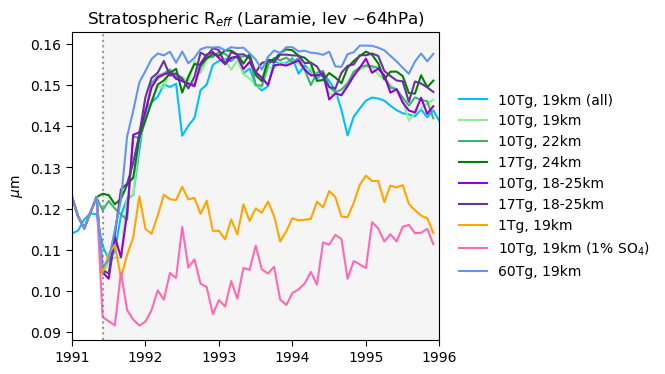

In [36]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(to_float(SReff_Laramie), SReff_Laramie, color="deepskyblue", label="10Tg, 19km (all)")
ax.plot(to_float(SReff_19_c_Laramie), SReff_19_c_Laramie, color="lightgreen", label="10Tg, 19km")
ax.plot(to_float(SReff_22_Laramie), SReff_22_Laramie, color="mediumseagreen", label="10Tg, 22km")
ax.plot(to_float(SReff_24_Laramie), SReff_24_Laramie, color="green", label="17Tg, 24km") 
ax.plot(to_float(SReff_1825_Laramie), SReff_1825_Laramie, color="darkviolet", label="10Tg, 18-25km")
ax.plot(to_float(SReff_1825_17tg_Laramie), SReff_1825_17tg_Laramie, color="rebeccapurple", label="17Tg, 18-25km")
ax.plot(to_float(SReff_1tg_Laramie), SReff_1tg_Laramie, color="orange", label="1Tg, 19km")
ax.plot(to_float(SReff_1pr_Laramie), SReff_1pr_Laramie, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax.plot(to_float(SReff_60tg_Laramie), SReff_60tg_Laramie, color="cornflowerblue", label="60Tg, 19km")

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12   

ax.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
ax.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
ax.tick_params(direction='out', length=4)

ax.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
ax.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
ax.set_xlim(1991, 1996)

fig.subplots_adjust(right=0.65)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
ax.set_ylabel("$\mu$m")
ax.set_title("Stratospheric R$_{eff}$ (Laramie, lev ~64hPa)")

In [37]:
SReff_Laramie_long = compute_SReff_hybrid(reff_data_19, p_lev_upper=p_lev_u, p_lev_lower = p_lev_l, lat_range=(40,42), lon_range=(105, 106.5))
SReff_Laramie_bc = SReff_Laramie_long.sel(time=slice("1986-01", "1990-12"))

SReff_long = compute_SReff_hybrid(reff_data_19, p_lev_upper=3.643466, p_lev_lower = p_lev)
SReff_bc = SReff_long.sel(time=slice("1986-01", "1990-12"))

SReff_trop_long = compute_SReff_hybrid(reff_data_19, p_lev_upper=3.643466, p_lev_lower = p_lev_trop, lat_range=(-20,20))
SReff_trop_bc = SReff_trop_long.sel(time=slice("1986-01", "1990-12"))

laramie_mean = float(SReff_Laramie_bc.mean(dim="time"))
laramie_std  = float(SReff_Laramie_bc.std(dim="time"))
global_mean = float(SReff_bc.mean(dim="time"))
global_std  = float(SReff_bc.std(dim="time"))
trop_mean = float(SReff_trop_bc.mean(dim="time"))
trop_std  = float(SReff_trop_bc.std(dim="time"))

<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1205441/2437241900.py:6: SyntaxWarning: invalid escape sequence '\p'
  color='gray', alpha=0.2, label='$\pm2\sigma$')
/tmp/ipykernel_1205441/2437241900.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_ylabel("Effective radius [$\mu$m]", fontsize=13)


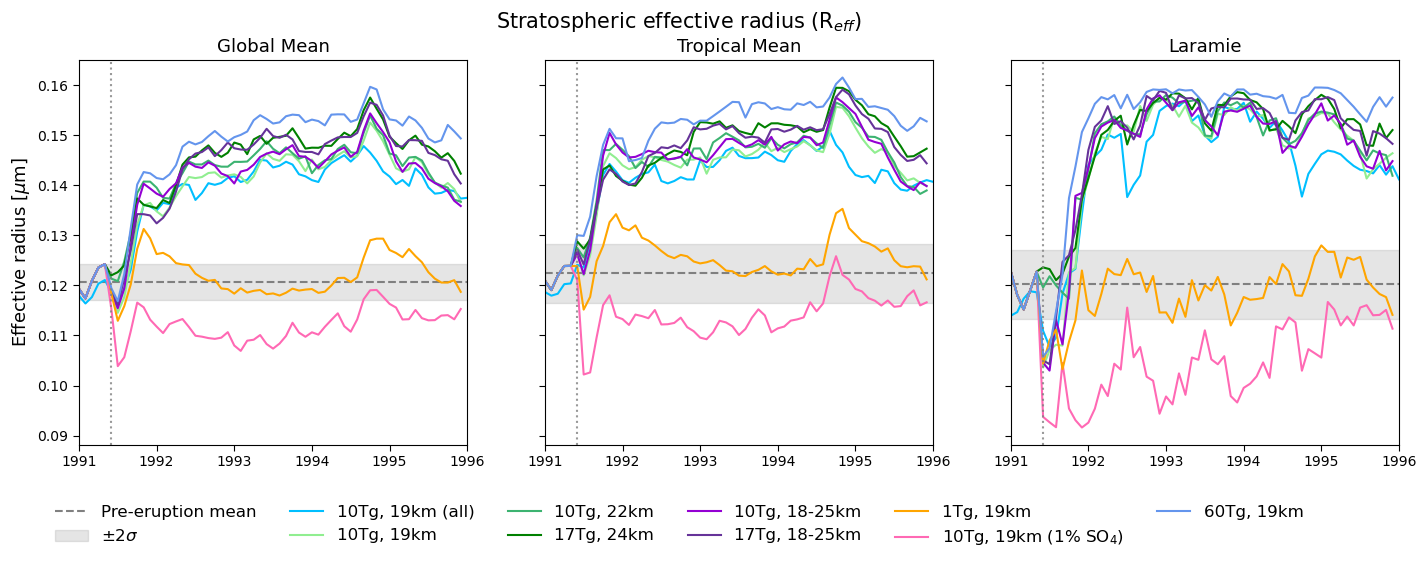

In [38]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
ax[0].axhline(global_mean, color='gray', linestyle='--', label='Pre-eruption mean')
ax[0].fill_between(to_float(SReff), 
                global_mean - 2*global_std, 
                global_mean + 2*global_std, 
                color='gray', alpha=0.2, label='$\pm2\sigma$')
ax[0].plot(to_float(SReff), SReff, color="deepskyblue", label="10Tg, 19km (all)")
ax[0].plot(to_float(SReff_19_c), SReff_19_c, color="lightgreen", label="10Tg, 19km")
ax[0].plot(to_float(SReff_22), SReff_22, color="mediumseagreen", label="10Tg, 22km")
ax[0].plot(to_float(SReff_24), SReff_24, color="green", label="17Tg, 24km") 
ax[0].plot(to_float(SReff_1825), SReff_1825, color="darkviolet", label="10Tg, 18-25km")
ax[0].plot(to_float(SReff_1825_17tg), SReff_1825_17tg, color="rebeccapurple", label="17Tg, 18-25km")
ax[0].plot(to_float(SReff_1tg), SReff_1tg, color="orange", label="1Tg, 19km")
ax[0].plot(to_float(SReff_1pr), SReff_1pr, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[0].plot(to_float(SReff_60tg), SReff_60tg, color="cornflowerblue", label="60Tg, 19km")
ax[0].set_ylabel("Effective radius [$\mu$m]", fontsize=13)
ax[0].set_title("Global Mean", fontsize=13)

ax[1].axhline(trop_mean, color='gray', linestyle='--')
ax[1].fill_between(to_float(SReff_trop), 
                trop_mean - 2*trop_std, 
                trop_mean + 2*trop_std, 
                color='gray', alpha=0.2)
ax[1].plot(to_float(SReff_trop), SReff_trop, color="deepskyblue", label="10Tg, 19km (all)")
ax[1].plot(to_float(SReff_19_c_trop), SReff_19_c_trop, color="lightgreen", label="10Tg, 19km")
ax[1].plot(to_float(SReff_22_trop), SReff_22_trop, color="mediumseagreen", label="10Tg, 22km")
ax[1].plot(to_float(SReff_24_trop), SReff_24_trop, color="green", label="17Tg, 24km") 
ax[1].plot(to_float(SReff_1825_trop), SReff_1825_trop, color="darkviolet", label="10Tg, 18-25km")
ax[1].plot(to_float(SReff_1825_17tg_trop), SReff_1825_17tg_trop, color="rebeccapurple", label="17Tg, 18-25km")
ax[1].plot(to_float(SReff_1pr_trop), SReff_1pr_trop, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[1].plot(to_float(SReff_1tg_trop), SReff_1tg_trop, color="orange", label="1Tg, 19km")
ax[1].plot(to_float(SReff_60tg_trop), SReff_60tg_trop, color="cornflowerblue", label="60Tg, 19km")
ax[1].set_title("Tropical Mean", fontsize=13)

ax[2].axhline(laramie_mean, color='gray', linestyle='--')
ax[2].fill_between(to_float(SReff_Laramie), 
                laramie_mean - 2*laramie_std, 
                laramie_mean + 2*laramie_std, 
                color='gray', alpha=0.2)
ax[2].plot(to_float(SReff_Laramie), SReff_Laramie, color="deepskyblue", label="10Tg, 19km (all)")
ax[2].plot(to_float(SReff_19_c_Laramie), SReff_19_c_Laramie, color="lightgreen", label="10Tg, 19km")
ax[2].plot(to_float(SReff_22_Laramie), SReff_22_Laramie, color="mediumseagreen", label="10Tg, 22km")
ax[2].plot(to_float(SReff_24_Laramie), SReff_24_Laramie, color="green", label="17Tg, 24km") 
ax[2].plot(to_float(SReff_1825_Laramie), SReff_1825_Laramie, color="darkviolet", label="10Tg, 18-25km")
ax[2].plot(to_float(SReff_1825_17tg_Laramie), SReff_1825_17tg_Laramie, color="rebeccapurple", label="17Tg, 18-25km")
ax[2].plot(to_float(SReff_1pr_Laramie), SReff_1pr_Laramie, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[2].plot(to_float(SReff_1tg_Laramie), SReff_1tg_Laramie, color="orange", label="1Tg, 19km")
ax[2].plot(to_float(SReff_60tg_Laramie), SReff_60tg_Laramie, color="cornflowerblue", label="60Tg, 19km")
ax[2].set_title("Laramie", fontsize=13)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12   

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)


handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.02),
    ncol = 6,
    frameon=False, fontsize = 12
)

fig.suptitle("Stratospheric effective radius (R$_{eff}$)", fontsize=15)
fig.subplots_adjust(right=0.95)
plt.show()

## With Observations

In [39]:
path_obs = "/nird/datapeak/NS1004K/elihho/obs_pinatubo/dataset/Observation"
sageii_tropreff = pd.read_csv(f"{path_obs}/sageii_tropical_reff.txt", delim_whitespace=True, header=0,  index_col=0)
start = pd.Timestamp("1991-01-01")
months_sageii = [int(c) for c in sageii_tropreff.columns]
dates_sageii = [start + pd.DateOffset(months=m) for m in months_sageii]
sageii_tropreff.columns = dates_sageii

/tmp/ipykernel_1205441/1079825040.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sageii_tropreff = pd.read_csv(f"{path_obs}/sageii_tropical_reff.txt", delim_whitespace=True, header=0,  index_col=0)


In [40]:
OPC_reff = pd.read_csv(f"{path_obs}/OPC_strat_reff.txt", delim_whitespace=True)
start_date = pd.Timestamp("1991-01-01")
OPC_reff['date'] = start_date + pd.to_timedelta(OPC_reff['Days_since_Jan_1991'], unit='D')

/tmp/ipykernel_1205441/238763274.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  OPC_reff = pd.read_csv(f"{path_obs}/OPC_strat_reff.txt", delim_whitespace=True)


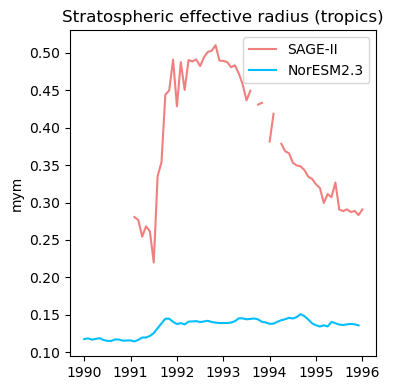

In [41]:
strat_reff_sageii = sageii_tropreff.loc["Strat_mean_sad_weighted"].astype(float)
cm_to_mym = 10000

SReff = reff_data_19["REFF_AERO"].where(reff_data_19["REFF_AERO"]["lev"] <= p_lev)
SReff_trop = SReff.sel(lat = slice(-20,20))
SReff_trop = SReff_trop.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"]) * cm_to_mym
SReff_trop = SReff_trop.sel(time=slice("1990-01-01", "1995-12-31"))

obs_time_sageii = np.array([t.year + (t.month-1)/12 for t in strat_reff_sageii.index])
time_years = np.array([t.year + (t.month-1)/12 for t in SReff_trop.time.values])

plt.figure(figsize=(4, 4))
plt.plot(obs_time_sageii, strat_reff_sageii, color = "lightcoral", label = "SAGE-II")
plt.plot(time_years, SReff_trop, color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("mym")
plt.title("Stratospheric effective radius (tropics)")
plt.legend()
plt.tight_layout()

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1205441/3616686844.py:15: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_ylabel("Effective radius [$\mu$m]", fontsize=12)


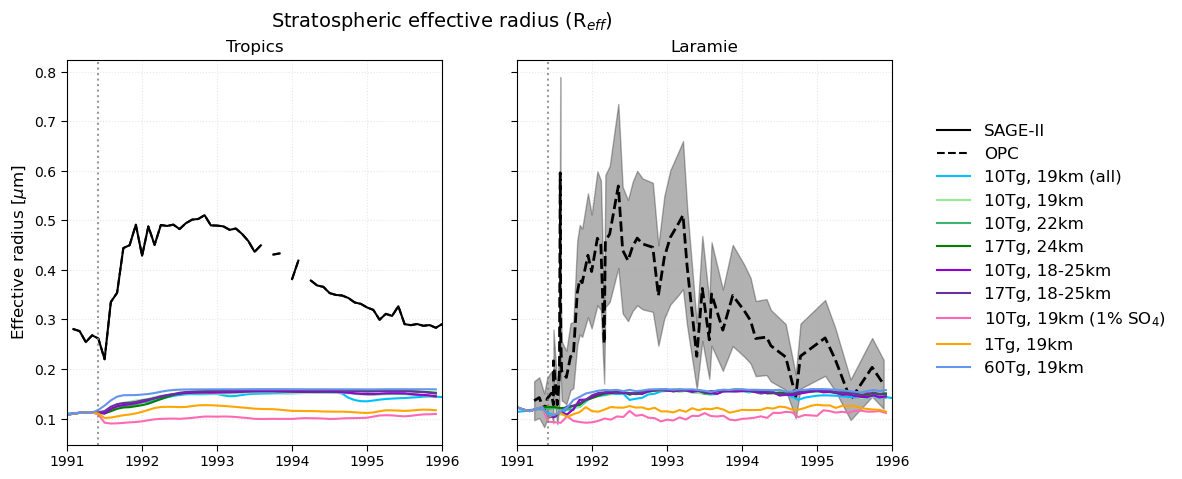

In [42]:
OPC_time = 1991 + (OPC_reff['Days_since_Jan_1991'] / 365.25)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(obs_time_sageii, strat_reff_sageii, color = "black", label = "SAGE-II")
ax[0].plot(obs_time_sageii, strat_reff_sageii, color = "black", label = "OPC", ls="--")
ax[0].plot(to_float(SReff_trop_obs), SReff_trop_obs, color="deepskyblue", label="10Tg, 19km (all)")
ax[0].plot(to_float(SReff_19_c_trop_obs), SReff_19_c_trop_obs, color="lightgreen", label="10Tg, 19km")
ax[0].plot(to_float(SReff_22_trop_obs), SReff_22_trop_obs, color="mediumseagreen", label="10Tg, 22km")
ax[0].plot(to_float(SReff_24_trop_obs), SReff_24_trop_obs, color="green", label="17Tg, 24km") 
ax[0].plot(to_float(SReff_1825_trop_obs), SReff_1825_trop_obs, color="darkviolet", label="10Tg, 18-25km")
ax[0].plot(to_float(SReff_1825_17tg_trop_obs), SReff_1825_17tg_trop_obs, color="rebeccapurple", label="17Tg, 18-25km")
ax[0].plot(to_float(SReff_1pr_trop_obs), SReff_1pr_trop_obs, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[0].plot(to_float(SReff_1tg_trop_obs), SReff_1tg_trop_obs, color="orange", label="1Tg, 19km")
ax[0].plot(to_float(SReff_60tg_trop_obs), SReff_60tg_trop_obs, color="cornflowerblue", label="60Tg, 19km")
ax[0].set_ylabel("Effective radius [$\mu$m]", fontsize=12)
ax[0].set_title("Tropics", fontsize=12)

ax[1].plot(OPC_time, OPC_reff['strat_reff'], color="black", label="OPC", lw=2, ls="--")
ax[1].fill_between(OPC_time, 
                 OPC_reff['strat_reff'] - OPC_reff['strat_reff_err'], 
                 OPC_reff['strat_reff'] + OPC_reff['strat_reff_err'], 
                 color="black", alpha=0.3)
ax[1].plot(to_float(SReff_Laramie), SReff_Laramie, color="deepskyblue", label="10Tg, 19km (all)")
ax[1].plot(to_float(SReff_19_c_Laramie), SReff_19_c_Laramie, color="lightgreen", label="10Tg, 19km")
ax[1].plot(to_float(SReff_22_Laramie), SReff_22_Laramie, color="mediumseagreen", label="10Tg, 22km")
ax[1].plot(to_float(SReff_24_Laramie), SReff_24_Laramie, color="green", label="17Tg, 24km") 
ax[1].plot(to_float(SReff_1825_Laramie), SReff_1825_Laramie, color="darkviolet", label="10Tg, 18-25km")
ax[1].plot(to_float(SReff_1825_17tg_Laramie), SReff_1825_17tg_Laramie, color="rebeccapurple", label="17Tg, 18-25km")
ax[1].plot(to_float(SReff_1pr_Laramie), SReff_1pr_Laramie, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[1].plot(to_float(SReff_1tg_Laramie), SReff_1tg_Laramie, color="orange", label="1Tg, 19km")
ax[1].plot(to_float(SReff_60tg_Laramie), SReff_60tg_Laramie, color="cornflowerblue", label="60Tg, 19km")
ax[1].set_title("Laramie", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12   

for i, a in enumerate(ax):
    a.grid(True, alpha=0.3, linestyle=':')
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)


handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False, fontsize=12
)

fig.suptitle("Stratospheric effective radius (R$_{eff}$)", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

## Aerosol microphysics

In [43]:
nmr01_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/NMR01_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in nmr01_19['time'].values])
nmr01_19 = nmr01_19.assign_coords(time=shifted_time_19)
nmr01_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/NMR01_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in nmr01_19_c['time'].values])
nmr01_19_c = nmr01_19_c.assign_coords(time=shifted_time_19_c)
nmr01_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/NMR01_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in nmr01_22['time'].values])
nmr01_22 = nmr01_22.assign_coords(time=shifted_time_22)
nmr01_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/NMR01_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in nmr01_24['time'].values])
nmr01_24 = nmr01_24.assign_coords(time=shifted_time_24)
nmr01_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/NMR01_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in nmr01_1825_17tg['time'].values])
nmr01_1825_17tg = nmr01_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
nmr01_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/NMR01_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in nmr01_1825['time'].values])
nmr01_1825 = nmr01_1825.assign_coords(time=shifted_time_1825)
nmr01_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/NMR01_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in nmr01_1tg['time'].values])
nmr01_1tg = nmr01_1tg.assign_coords(time=shifted_time_1tg)
nmr01_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/NMR01_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in nmr01_1pr['time'].values])
nmr01_1pr = nmr01_1pr.assign_coords(time=shifted_time_1pr)
nmr01_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/NMR01_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in nmr01_60tg['time'].values])
nmr01_60tg = nmr01_60tg.assign_coords(time=shifted_time_60tg)

<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1205441/1209171783.py:36: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("[$\mu$m]" if ax in axs[:, 0] else "")


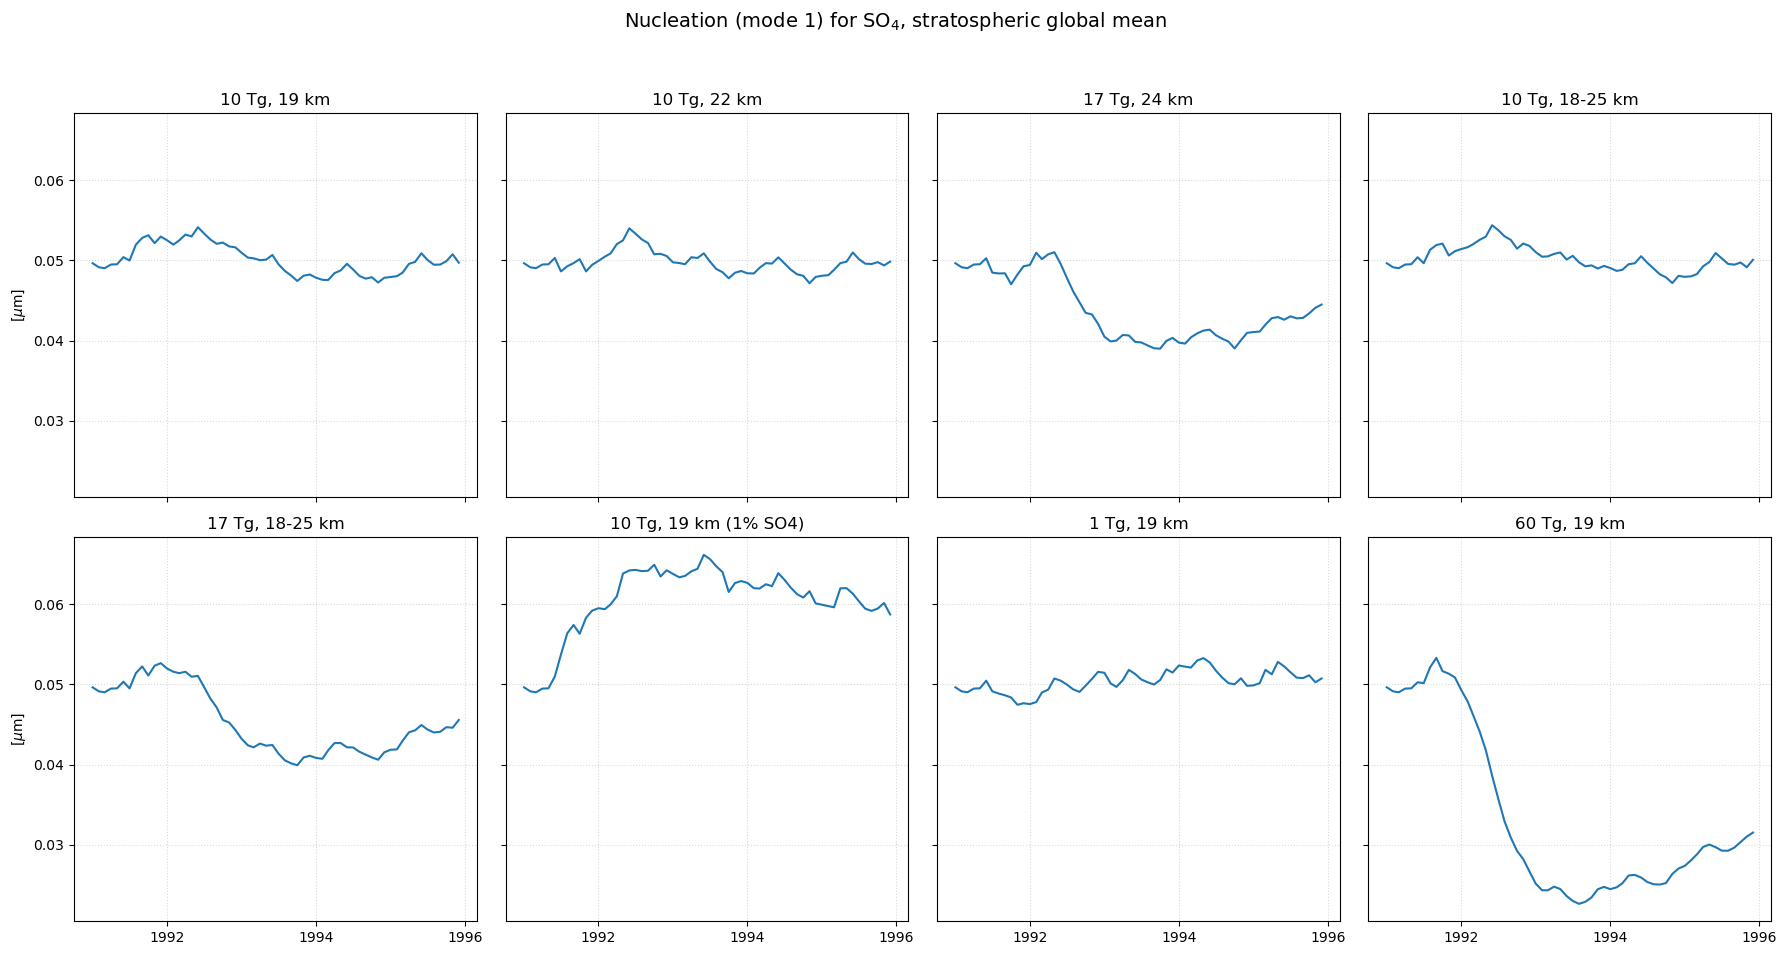

In [44]:
so4_modes = ["01", "05"]
m_to_mym = cm_to_mym*100
ds = [nmr01_19_c, nmr01_22, nmr01_24, 
      nmr01_1825, nmr01_1825_17tg, nmr01_1pr, 
      nmr01_1tg, nmr01_60tg]
levels = [p_lev_19_c, p_lev_22, p_lev_24, 
          p_lev_1825, p_lev_1825_17tg, p_lev_1pr,
          p_lev_1tg, p_lev_60tg]
weights = [weighted_lat_19_c, weighted_lat_22, weighted_lat_24,
           weighted_lat_1825, weighted_lat_1825_17tg, weighted_lat_1pr,
           weighted_lat_1tg, weighted_lat_60tg]

titles = ["10 Tg, 19 km", 
          "10 Tg, 22 km", 
          "17 Tg, 24 km", 
          "10 Tg, 18-25 km", 
          "17 Tg, 18-25 km", 
          "10 Tg, 19 km (1% SO4)", 
          "1 Tg, 19 km", 
          "60 Tg, 19 km"]

fig, axs = plt.subplots(2, 4, figsize=(18, 10), sharex=True, sharey=True)

for ax, current_ds, w, p, title in zip(axs.flat, ds, weights, levels, titles):
    lev_vals = current_ds.lev.values
    lev_diff = np.abs(np.gradient(lev_vals))
    wl = xr.DataArray(lev_diff, coords={'lev': current_ds.lev}, dims=['lev'])
    
    nmr_raw = current_ds["NMR01"].where(current_ds["lev"] <= p)
    
    nmr_h = nmr_raw.weighted(w).mean(dim=["lat", "lon"])
    nmr_final = nmr_h.weighted(wl).mean(dim="lev") * m_to_mym
    nmr_final.plot(ax=ax)
    
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("[$\mu$m]" if ax in axs[:, 0] else "")
    ax.set_xlabel("") 
    ax.grid(color="gray", alpha=0.3, linestyle=":")

plt.suptitle("Nucleation (mode 1) for SO$_4$, stratospheric global mean", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [45]:
nmr05_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/NMR05_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in nmr05_19['time'].values])
nmr05_19 = nmr05_19.assign_coords(time=shifted_time_19)
nmr05_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/NMR05_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in nmr05_19_c['time'].values])
nmr05_19_c = nmr05_19_c.assign_coords(time=shifted_time_19_c)
nmr05_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/NMR05_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in nmr05_22['time'].values])
nmr05_22 = nmr05_22.assign_coords(time=shifted_time_22)
nmr05_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/NMR05_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in nmr05_24['time'].values])
nmr05_24 = nmr05_24.assign_coords(time=shifted_time_24)
nmr05_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/NMR05_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in nmr05_1825_17tg['time'].values])
nmr05_1825_17tg = nmr05_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
nmr05_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/NMR05_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in nmr05_1825['time'].values])
nmr05_1825 = nmr05_1825.assign_coords(time=shifted_time_1825)
nmr05_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/NMR05_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in nmr05_1tg['time'].values])
nmr05_1tg = nmr05_1tg.assign_coords(time=shifted_time_1tg)
nmr05_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/NMR05_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in nmr05_1pr['time'].values])
nmr05_1pr = nmr05_1pr.assign_coords(time=shifted_time_1pr)
nmr05_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/NMR05_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in nmr05_60tg['time'].values])
nmr05_60tg = nmr05_60tg.assign_coords(time=shifted_time_60tg)

<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1205441/3726662708.py:35: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("[$\mu$m]" if ax in axs[:, 0] else "")


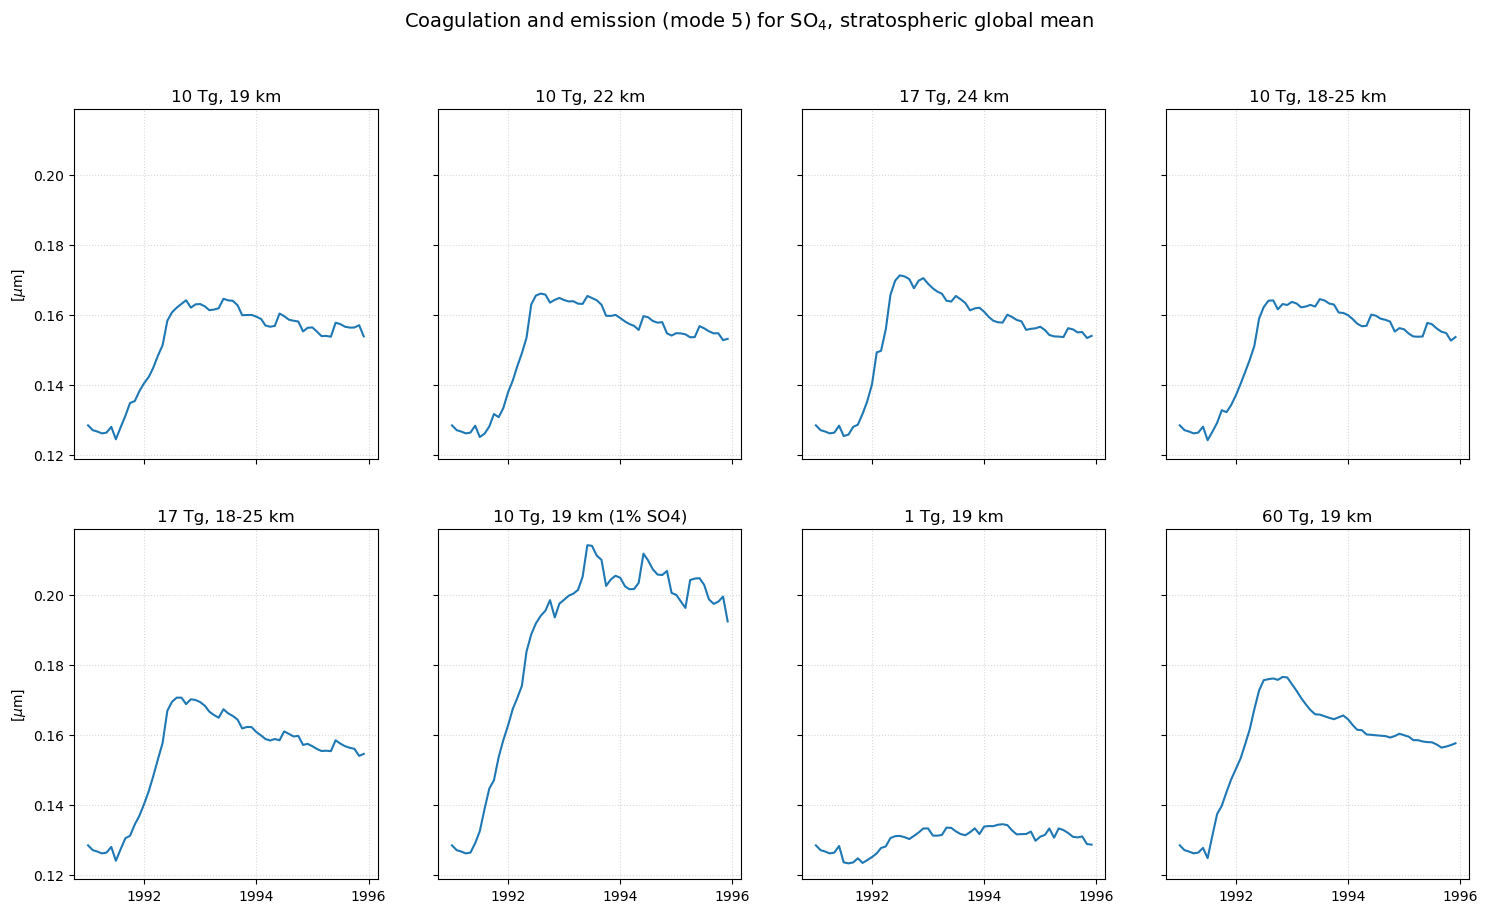

In [46]:
so4_modes = ["01", "05"]
ds = [nmr05_19_c, nmr05_22, nmr05_24, 
      nmr05_1825, nmr05_1825_17tg, nmr05_1pr, 
      nmr05_1tg, nmr05_60tg]
levels = [p_lev_19_c, p_lev_22, p_lev_24, 
          p_lev_1825, p_lev_1825_17tg, p_lev_1pr,
          p_lev_1tg, p_lev_60tg]
weights = [weighted_lat_19_c, weighted_lat_22, weighted_lat_24,
           weighted_lat_1825, weighted_lat_1825_17tg, weighted_lat_1pr,
           weighted_lat_1tg, weighted_lat_60tg]

titles = ["10 Tg, 19 km", 
          "10 Tg, 22 km", 
          "17 Tg, 24 km", 
          "10 Tg, 18-25 km", 
          "17 Tg, 18-25 km", 
          "10 Tg, 19 km (1% SO4)", 
          "1 Tg, 19 km", 
          "60 Tg, 19 km"]

fig, axs = plt.subplots(2, 4, figsize=(18, 10), sharex=True, sharey=True)

for ax, current_ds, w, p, title in zip(axs.flat, ds, weights, levels, titles):
    lev_vals = current_ds.lev.values
    lev_diff = np.abs(np.gradient(lev_vals))
    wl = xr.DataArray(lev_diff, coords={'lev': current_ds.lev}, dims=['lev'])
    
    nmr_raw = current_ds["NMR05"].where(current_ds["lev"] <= p)
    
    nmr_h = nmr_raw.weighted(w).mean(dim=["lat", "lon"])
    nmr_final = nmr_h.weighted(wl).mean(dim="lev") * m_to_mym
    nmr_final.plot(ax=ax)
    
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("[$\mu$m]" if ax in axs[:, 0] else "")
    ax.set_xlabel("") 
    ax.grid(color="gray", alpha=0.3, linestyle=":")

plt.suptitle("Coagulation and emission (mode 5) for SO$_4$, stratospheric global mean", fontsize=14)
plt.show()

<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1205441/2173389409.py:58: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel(f"Radius [$\mu$m]", fontsize=12)


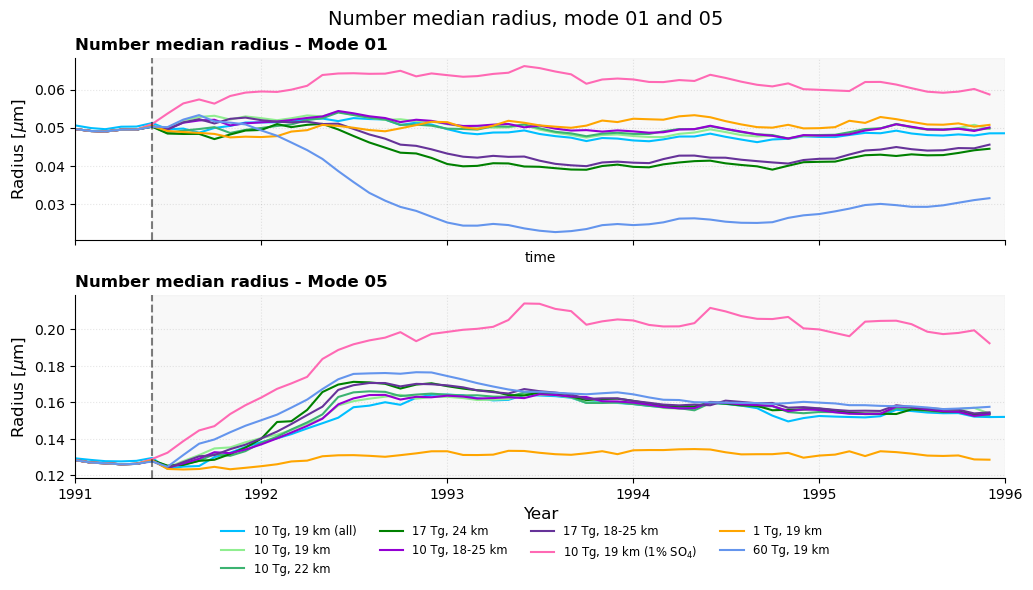

In [47]:
so4_modes = ["01", "05"]
nmr01_19_pin = nmr01_19.sel(time=slice("1991", "1996"))
nmr05_19_pin = nmr05_19.sel(time=slice("1991", "1996"))

ds_nmr01 = [nmr01_19_pin, nmr01_19_c, nmr01_22, nmr01_24, 
      nmr01_1825, nmr01_1825_17tg, nmr01_1pr, 
      nmr01_1tg, nmr01_60tg]

ds_nmr05 = [nmr05_19_pin, nmr05_19_c, nmr05_22, nmr05_24, 
      nmr05_1825, nmr05_1825_17tg, nmr05_1pr, 
      nmr05_1tg, nmr05_60tg]

mode_data_mapper = {
    "01": ds_nmr01,
    "05": ds_nmr05
}
levels = [p_lev, p_lev_19_c, p_lev_22, p_lev_24, 
          p_lev_1825, p_lev_1825_17tg, p_lev_1pr, 
          p_lev_1tg, p_lev_60tg]

weights = [weighted_lat, weighted_lat_19_c, weighted_lat_22, weighted_lat_24, 
           weighted_lat_1825, weighted_lat_1825_17tg, weighted_lat_1pr, 
           weighted_lat_1tg, weighted_lat_60tg]

labels = ["10 Tg, 19 km (all)",
          "10 Tg, 19 km", 
          "10 Tg, 22 km", 
          "17 Tg, 24 km", 
          "10 Tg, 18-25 km", 
          "17 Tg, 18-25 km", 
          "10 Tg, 19 km (1% SO$_4$)", 
          "1 Tg, 19 km", 
          "60 Tg, 19 km"]

colors =["deepskyblue", "lightgreen", "mediumseagreen", "green", "darkviolet", "rebeccapurple", "hotpink", "orange", "cornflowerblue"]

eruption_date = cftime.DatetimeNoLeap(1991, 6, 1)
end_date = cftime.DatetimeNoLeap(1996, 1, 1)

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for i, mode in enumerate(so4_modes):
    ax = axs[i]
    current_ds_list = mode_data_mapper[mode]
    
    for d, w, p, label, color in zip(current_ds_list, weights, levels, labels, colors):
        var_name = f"NMR{mode}"
        
        lev_vals = d.lev.values
        lev_diff = np.abs(np.gradient(lev_vals))
        wl = xr.DataArray(lev_diff, coords={'lev': d.lev}, dims=['lev'])
        
        nmr = d[var_name].where(d["lev"] <= p)
        nmr_h = nmr.weighted(w).mean(dim=["lat", "lon"])
        nmr_final = nmr_h.weighted(wl).mean(dim="lev") * m_to_mym
        nmr_final.plot(ax=ax, color=color, label=label, add_legend=False)
    
    ax.set_ylabel(f"Radius [$\mu$m]", fontsize=12)
    ax.set_title(f"Number median radius - Mode {mode}", loc='left', fontweight='bold')
    ax.grid(True, color="gray", alpha=0.2, linestyle=":")
    
    ax.axvline(eruption_date, color='black', ls="--", alpha=0.5)
    ax.axvspan(eruption_date, end_date, color='gray', alpha=0.05, zorder=0)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles, labels_legend = axs[0].get_legend_handles_labels()
fig.legend(
    handles, 
    labels_legend, 
    loc="lower center", 
    bbox_to_anchor=(0.5, 0.02), 
    ncol=4, 
    frameon=False, 
    fontsize='small'
)

years = np.arange(1991, 1997)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
axs[1].set_xticks(year_ticks)
axs[1].set_xticklabels([str(y) for y in years])
axs[1].set_xlabel("Year", fontsize=12)
axs[1].set_xlim(cftime.DatetimeNoLeap(1991, 1, 1), cftime.DatetimeNoLeap(1996, 1, 1))

plt.suptitle("Number median radius, mode 01 and 05", fontsize=14)

plt.subplots_adjust(bottom=0.2, hspace=0.3, top=0.9)
plt.show()

In [48]:
NCONC01_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/NCONC01_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in NCONC01_19['time'].values])
NCONC01_19 = NCONC01_19.assign_coords(time=shifted_time_19)
NCONC01_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/NCONC01_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in NCONC01_19_c['time'].values])
NCONC01_19_c = NCONC01_19_c.assign_coords(time=shifted_time_19_c)
NCONC01_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/NCONC01_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in NCONC01_22['time'].values])
NCONC01_22 = NCONC01_22.assign_coords(time=shifted_time_22)
NCONC01_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/NCONC01_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in NCONC01_24['time'].values])
NCONC01_24 = NCONC01_24.assign_coords(time=shifted_time_24)
NCONC01_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/NCONC01_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in NCONC01_1825_17tg['time'].values])
NCONC01_1825_17tg = NCONC01_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
NCONC01_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/NCONC01_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in NCONC01_1825['time'].values])
NCONC01_1825 = NCONC01_1825.assign_coords(time=shifted_time_1825)
NCONC01_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/NCONC01_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in NCONC01_1tg['time'].values])
NCONC01_1tg = NCONC01_1tg.assign_coords(time=shifted_time_1tg)
NCONC01_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/NCONC01_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in NCONC01_1pr['time'].values])
NCONC01_1pr = NCONC01_1pr.assign_coords(time=shifted_time_1pr)
NCONC01_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/NCONC01_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in NCONC01_60tg['time'].values])
NCONC01_60tg = NCONC01_60tg.assign_coords(time=shifted_time_60tg)

In [49]:
NCONC01_19

<xarray.Dataset> Size: 3GB
Dimensions:    (lat: 192, lon: 288, lev: 32, ilev: 33, time: 478, nbnd: 2)
Coordinates:
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * lev        (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * ilev       (ilev) float64 264B 2.255 5.032 10.16 18.56 ... 967.5 985.1 1e+03
  * time       (time) object 4kB 1975-01-01 00:00:00 ... 2014-11-01 00:00:00
Dimensions without coordinates: nbnd
Data variables:
    hyam       (lev) float64 256B ...
    hybm       (lev) float64 256B ...
    P0         float64 8B ...
    hyai       (ilev) float64 264B ...
    hybi       (ilev) float64 264B ...
    time_bnds  (time, nbnd) object 8kB ...
    NCONC01    (time, lev, lat, lon) float32 3GB ...
    PS         (time, lat, lon) float32 106MB ...
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              NHIST_tropstratchem_f09_tn14_20250917_1975_2014
    logname:           elihho
    host:              
    initial_file:      NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03....
    topography_file:   /cluster/shared/noresm/inputdata/atm/cam/topo/fv_0.9x1...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  month_1
    history:           Tue Apr  7 21:42:51 2026: ncrcat -O -v NCONC01 /nird/d...
    NCO:               netCDF Operators version 5.3.0 (Homepage = http://nco....

In [50]:
NCONC05_19 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_pinatubo/NHIST_tropstratchem_f09_tn14_20250917_1975_2014/NCONC05_h0_1975-2014.nc")
shifted_time_19 = np.array([shift_one_month_back(t) for t in NCONC05_19['time'].values])
NCONC05_19 = NCONC05_19.assign_coords(time=shifted_time_19)
NCONC05_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/NCONC05_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in NCONC05_19_c['time'].values])
NCONC05_19_c = NCONC05_19_c.assign_coords(time=shifted_time_19_c)
NCONC05_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/NCONC05_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in NCONC05_22['time'].values])
NCONC05_22 = NCONC05_22.assign_coords(time=shifted_time_22)
NCONC05_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/NCONC05_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in NCONC05_24['time'].values])
NCONC05_24 = NCONC05_24.assign_coords(time=shifted_time_24)
NCONC05_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/NCONC05_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in NCONC05_1825_17tg['time'].values])
NCONC05_1825_17tg = NCONC05_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
NCONC05_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/NCONC05_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in NCONC05_1825['time'].values])
NCONC05_1825 = NCONC05_1825.assign_coords(time=shifted_time_1825)
NCONC05_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/NCONC05_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in NCONC05_1tg['time'].values])
NCONC05_1tg = NCONC05_1tg.assign_coords(time=shifted_time_1tg)
NCONC05_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/NCONC05_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in NCONC05_1pr['time'].values])
NCONC05_1pr = NCONC05_1pr.assign_coords(time=shifted_time_1pr)
NCONC05_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/NCONC05_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in NCONC05_60tg['time'].values])
NCONC05_60tg = NCONC05_60tg.assign_coords(time=shifted_time_60tg)

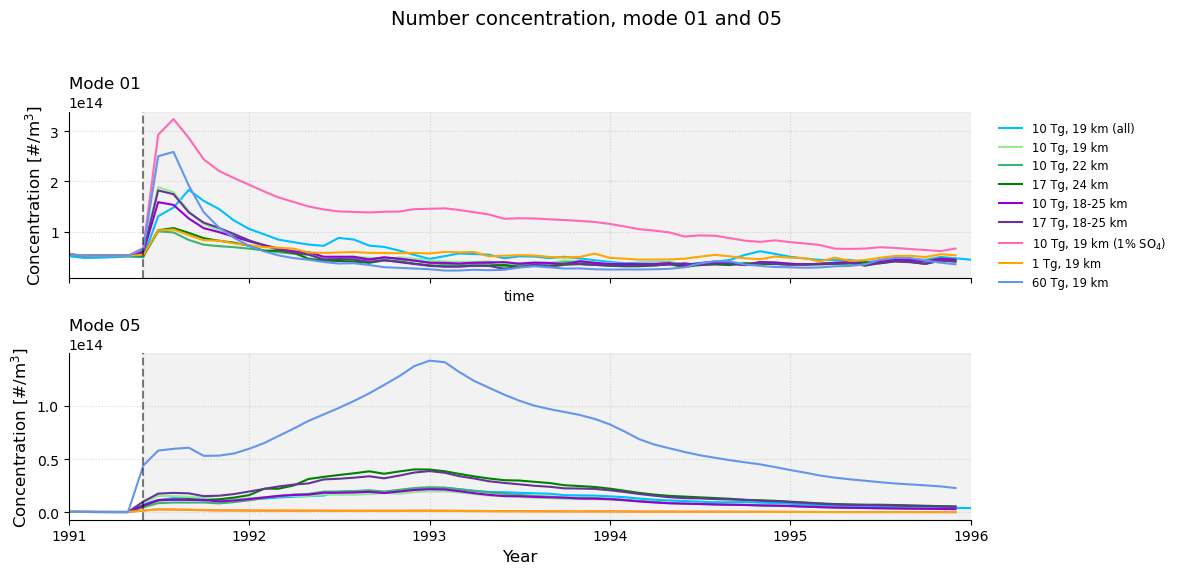

In [51]:
NCONC01_19_pin = NCONC01_19.sel(time=slice("1991", "1996"))
NCONC05_19_pin = NCONC05_19.sel(time=slice("1991", "1996"))

ds_nconc01 = [NCONC01_19_pin, NCONC01_19_c, NCONC01_22, NCONC01_24, 
      NCONC01_1825, NCONC01_1825_17tg, NCONC01_1pr, 
      NCONC01_1tg, NCONC01_60tg]

ds_nconc05 = [NCONC05_19_pin, NCONC05_19_c, NCONC05_22, NCONC05_24, 
      NCONC05_1825, NCONC05_1825_17tg, NCONC05_1pr, 
      NCONC05_1tg, NCONC05_60tg]

mode_data_nconc = {
    "01": ds_nconc01,
    "05": ds_nconc05
}

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
eruption_date = cftime.DatetimeNoLeap(1991, 6, 1)
end_date = cftime.DatetimeNoLeap(1996, 1, 1)
for i, mode in enumerate(so4_modes):
    ax = axs[i]
    current_ds_list = mode_data_nconc[mode]
    for d, w, p, label, color in zip(current_ds_list, weights, levels, labels, colors):
        var_name = f"NCONC{mode}"
        
        lev_vals = d.lev.values
        lev_diff = np.abs(np.gradient(lev_vals))
        wl = xr.DataArray(lev_diff, coords={'lev': d.lev}, dims=['lev'])
        
        nconc = d[var_name].where(d["lev"] <= p)
    
        nconc_h = nconc.weighted(w).mean(dim=["lat", "lon"])
        nconc_final = nconc_h.weighted(wl).mean(dim="lev") * m_to_mym
        
        nconc_final.plot(ax=ax, color=color, label=label, add_legend=False)
    
    ax.set_ylabel(f"Concentration [#/m$^3$]", fontsize=12)
    ax.set_title(f"Mode {mode}", loc='left')
    ax.grid(True, color="gray", alpha=0.3, linestyle=":")
    
    ax.axvline(eruption_date, color='black', ls="--", alpha=0.5)
    ax.axvspan(eruption_date, end_date, color='gray', alpha=0.1, zorder=0)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    if i == 0:
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize='small', frameon=False)

years = np.arange(1991, 1997)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
ax.set_xticks(year_ticks)
ax.set_xticklabels([str(y) for y in years])
ax.set_xlabel("Year", fontsize=12)

ax.set_xlim(cftime.DatetimeNoLeap(1991, 1, 1), cftime.DatetimeNoLeap(1996, 1, 1))
plt.suptitle("Number concentration, mode 01 and 05", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1205441/1759100446.py:21: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("R$_{eff}$ [$\mu$m]", fontsize=12)


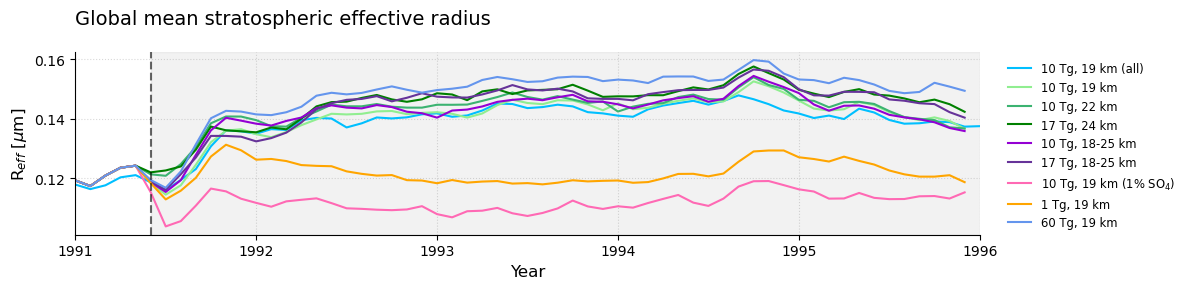

In [52]:
SReff = compute_SReff_hybrid(reff_data_19, p_lev_upper=3.643466, p_lev_lower=p_lev).sel(time=slice("1991-01-01", "1996-01-01"))
experiments = [SReff, SReff_19_c, SReff_22, SReff_24, SReff_1825, SReff_1825_17tg, SReff_1pr, SReff_1tg, SReff_60tg]

eruption_float = 1991 + (6-1)/12
end_float = 1996 

fig, ax = plt.subplots(1, 1, figsize=(12, 3))

for e, label, color in zip(experiments, labels, colors):
    x = to_float(e)
    y = e.values
    
    if np.nanmax(y) < 1e-3:
        y = y * 1e6
        
    ax.plot(x, y, color=color, label=label, linewidth=1.5)

ax.axvline(eruption_float, color='black', ls="--", alpha=0.6)
ax.axvspan(eruption_float, end_float, color='gray', alpha=0.1, zorder=0)

ax.set_ylabel("R$_{eff}$ [$\mu$m]", fontsize=12)
ax.set_xlabel("Year", fontsize=12)
ax.grid(True, color="gray", alpha=0.3, linestyle=":")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

years = np.arange(1991, 1997)
ax.set_xticks(years)
ax.set_xticklabels([str(y) for y in years])
ax.set_xlim(1991, 1996)

ax.relim()
ax.autoscale_view()

ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize='small', frameon=False)
plt.title("Global mean stratospheric effective radius", fontsize=14, loc='left', pad=20)

plt.tight_layout()
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1205441/3895989685.py:5: SyntaxWarning: invalid escape sequence '\m'
  ("Number Median Radius: Mode 01", "NMR", "01", "[$\mu$m]", ds_nmr01),
/tmp/ipykernel_1205441/3895989685.py:6: SyntaxWarning: invalid escape sequence '\m'
  ("Number Median Radius: Mode 05", "NMR", "05", "[$\mu$m]", ds_nmr05),
/tmp/ipykernel_1205441/3895989685.py:9: SyntaxWarning: invalid escape sequence '\m'
  ("Stratospheric Effective Radius", "SREFF", "", "[$\mu$m]", experiments)


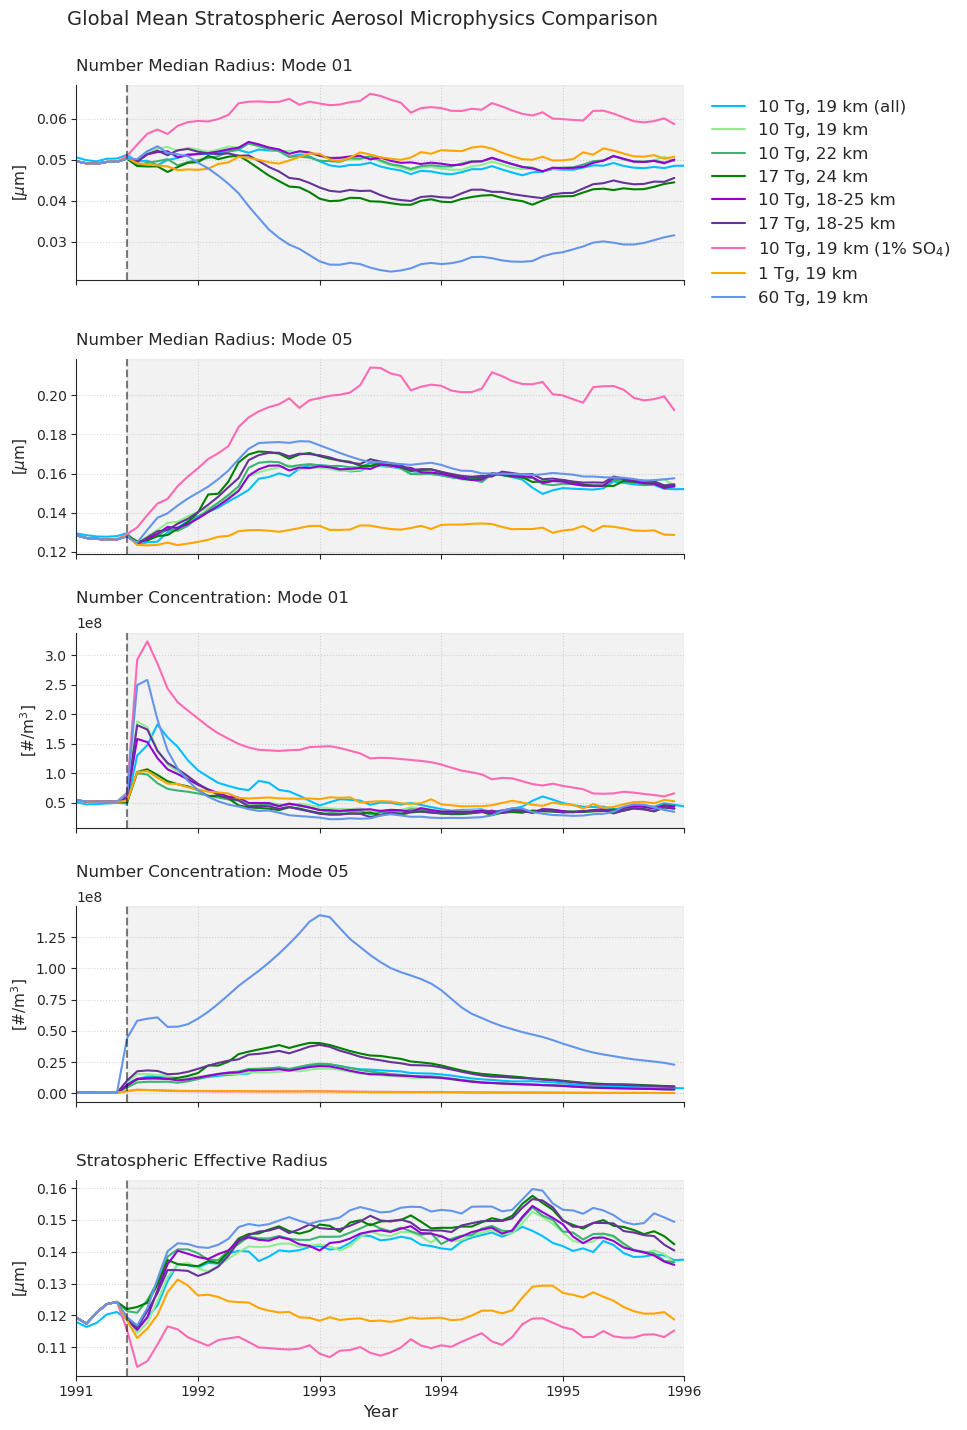

In [53]:
sns.set_style("ticks")
fig, axs = plt.subplots(5, 1, figsize=(12, 15), sharex=True)

panel_info = [
    ("Number Median Radius: Mode 01", "NMR", "01", "[$\mu$m]", ds_nmr01),
    ("Number Median Radius: Mode 05", "NMR", "05", "[$\mu$m]", ds_nmr05),
    ("Number Concentration: Mode 01", "NCONC", "01", "[#/m$^3$]", ds_nconc01),
    ("Number Concentration: Mode 05", "NCONC", "05", "[#/m$^3$]", ds_nconc05),
    ("Stratospheric Effective Radius", "SREFF", "", "[$\mu$m]", experiments)
]

eruption_float = 1991 + (6-1)/12
end_float = 1996 

for i, (title, var_prefix, mode, unit, current_ds_list) in enumerate(panel_info):
    ax = axs[i]
    
    if var_prefix != "SREFF":
        for d, w, p, label, color in zip(current_ds_list, weights, levels, labels, colors):
            
            lev_vals = d.lev.values
            lev_diff = np.abs(np.gradient(lev_vals))
            wl = xr.DataArray(lev_diff, coords={'lev': d.lev}, dims=['lev'])
            
            var_name = f"{var_prefix}{mode}"
            raw_data = d[var_name].where(d["lev"] <= p)
            h_mean = raw_data.weighted(w).mean(dim=["lat", "lon"])
            
            data = h_mean.weighted(wl).mean(dim="lev")
            
            if var_prefix == "NMR":
                data = data * m_to_mym
                
            ax.plot(to_float(data), data, color=color, label=label)
            
    else:
        for e, label, color in zip(current_ds_list, labels, colors):
            x_vals = to_float(e)
            
            y_vals = e.values
            if np.nanmax(y_vals) < 1e-3: 
                y_vals = y_vals * 1e6
            
            ax.plot(x_vals, y_vals, color=color, label=label, linewidth=1.5)

    ax.set_title(title, loc='left', fontsize=12, pad=10)
    ax.set_ylabel(unit, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, color="gray", alpha=0.3, linestyle=":")
    
    ax.axvline(eruption_float, color='black', ls="--", alpha=0.5)
    ax.axvspan(eruption_float, end_float, color='gray', alpha=0.1, zorder=0)
    
    if i == 0:
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=12, frameon=False)

years = np.arange(1991, 1997)
axs[-1].set_xticks(years)
axs[-1].set_xticklabels([str(y) for y in years])
axs[-1].set_xlabel("Year", fontsize=12)
axs[-1].set_xlim(1991, 1996)

plt.suptitle("Global Mean Stratospheric Aerosol Microphysics Comparison", fontsize=14, x=0.06, 
             horizontalalignment='left')

plt.tight_layout(rect=[0, 0.03, 0.82, 0.98]) 
plt.subplots_adjust(hspace=0.4)

plt.show()

<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1205441/1853760956.py:44: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel(f"Radius [$\mu$m]", fontsize=12)


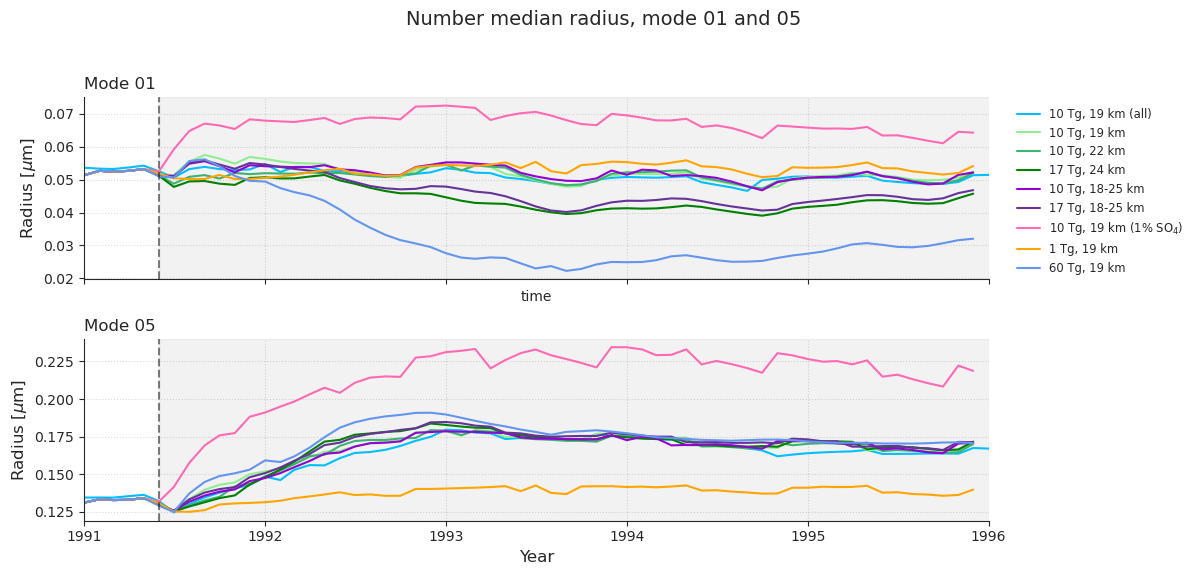

In [54]:
so4_modes = ["01", "05"]
levels = [p_lev_trop, p_lev_19_c_trop, p_lev_22_trop, p_lev_24_trop, 
          p_lev_1825_trop, p_lev_1825_17tg_trop, p_lev_1pr_trop, 
          p_lev_1tg_trop, p_lev_60tg_trop]

weights = [weighted_lat, weighted_lat_19_c, weighted_lat_22, weighted_lat_24, 
           weighted_lat_1825, weighted_lat_1825_17tg, weighted_lat_1pr, 
           weighted_lat_1tg, weighted_lat_60tg]

labels = ["10 Tg, 19 km (all)",
          "10 Tg, 19 km", 
          "10 Tg, 22 km", 
          "17 Tg, 24 km", 
          "10 Tg, 18-25 km", 
          "17 Tg, 18-25 km", 
          "10 Tg, 19 km (1% SO$_4$)", 
          "1 Tg, 19 km", 
          "60 Tg, 19 km"]

colors =["deepskyblue", "lightgreen", "mediumseagreen", "green", "darkviolet", "rebeccapurple", "hotpink", "orange", "cornflowerblue"]

eruption_date = cftime.DatetimeNoLeap(1991, 6, 1)
end_date = cftime.DatetimeNoLeap(1996, 1, 1)

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for i, mode in enumerate(so4_modes):
    ax = axs[i]
    current_ds_list = mode_data_mapper[mode]
    for d, w, p, label, color in zip(current_ds_list, weights, levels, labels, colors):
        var_name = f"NMR{mode}"
        
        lev_vals = d.lev.values
        lev_diff = np.abs(np.gradient(lev_vals))
        wl = xr.DataArray(lev_diff, coords={'lev': d.lev}, dims=['lev'])
        
        nmr = d[var_name].where(d["lev"] <= p)
        w_sliced = w.sel(lat=slice(-20, 20))
        nmr_h = nmr.sel(lat=slice(-20,20)).weighted(w_sliced).mean(dim=["lat", "lon"])
        nmr_final = nmr_h.weighted(wl).mean(dim="lev") * m_to_mym
        
        nmr_final.plot(ax=ax, color=color, label=label, add_legend=False)
    
    ax.set_ylabel(f"Radius [$\mu$m]", fontsize=12)
    ax.set_title(f"Mode {mode}", loc='left')
    ax.grid(True, color="gray", alpha=0.3, linestyle=":")
    
    ax.axvline(eruption_date, color='black', ls="--", alpha=0.5)
    ax.axvspan(eruption_date, end_date, color='gray', alpha=0.1, zorder=0)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    if i == 0:
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize='small', frameon=False)

years = np.arange(1991, 1997)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
ax.set_xticks(year_ticks)
ax.set_xticklabels([str(y) for y in years])
ax.set_xlabel("Year", fontsize=12)

ax.set_xlim(cftime.DatetimeNoLeap(1991, 1, 1), cftime.DatetimeNoLeap(1996, 1, 1))
plt.suptitle("Number median radius, mode 01 and 05", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

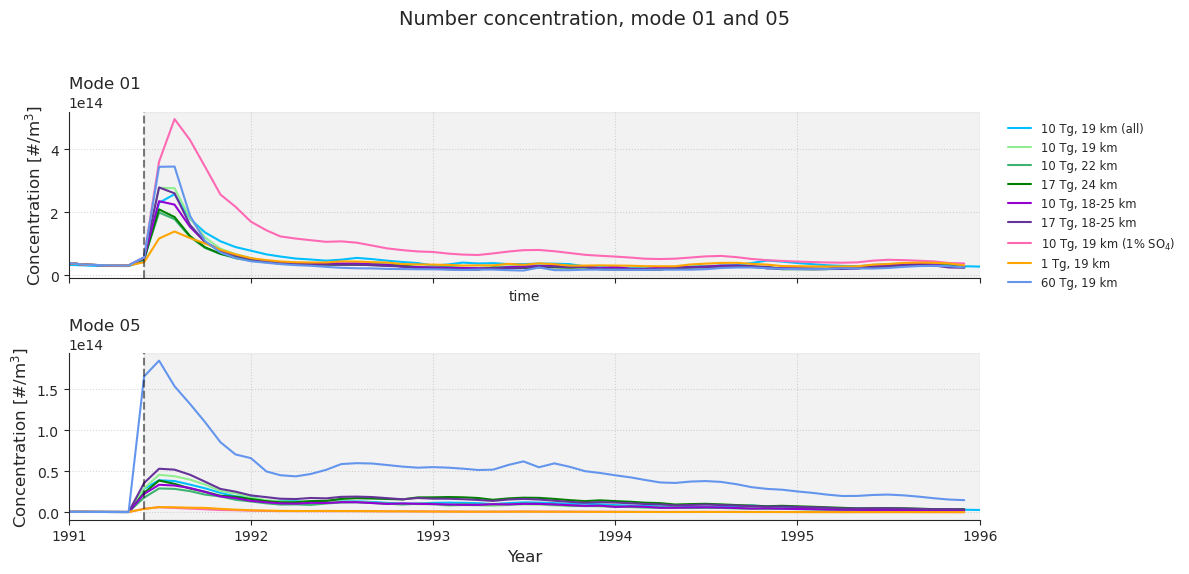

In [55]:
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
eruption_date = cftime.DatetimeNoLeap(1991, 6, 1)
end_date = cftime.DatetimeNoLeap(1996, 1, 1)
for i, mode in enumerate(so4_modes):
    ax = axs[i]
    current_ds_list = mode_data_nconc[mode]
    for d, w, p, label, color in zip(current_ds_list, weights, levels, labels, colors):
        var_name = f"NCONC{mode}"
        
        lev_vals = d.lev.values
        lev_diff = np.abs(np.gradient(lev_vals))
        wl = xr.DataArray(lev_diff, coords={'lev': d.lev}, dims=['lev'])
        
        nconc = d[var_name].where(d["lev"] <= p)
        w_sliced = w.sel(lat=slice(-20, 20))
        nconc_h = nconc.sel(lat=slice(-20,20)).weighted(w_sliced).mean(dim=["lat", "lon"])
        nconc_final = nconc_h.weighted(wl).mean(dim="lev") * m_to_mym
        
        nconc_final.plot(ax=ax, color=color, label=label, add_legend=False)
    
    ax.set_ylabel(f"Concentration [#/m$^3$]", fontsize=12)
    ax.set_title(f"Mode {mode}", loc='left')
    ax.grid(True, color="gray", alpha=0.3, linestyle=":")
    
    ax.axvline(eruption_date, color='black', ls="--", alpha=0.5)
    ax.axvspan(eruption_date, end_date, color='gray', alpha=0.1, zorder=0)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    if i == 0:
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize='small', frameon=False)

years = np.arange(1991, 1997)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
ax.set_xticks(year_ticks)
ax.set_xticklabels([str(y) for y in years])
ax.set_xlabel("Year", fontsize=12)

ax.set_xlim(cftime.DatetimeNoLeap(1991, 1, 1), cftime.DatetimeNoLeap(1996, 1, 1))
plt.suptitle("Number concentration, mode 01 and 05", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1205441/3799132462.py:7: SyntaxWarning: invalid escape sequence '\m'
  ("Number Median Radius: Mode 01", "NMR", "01", "[$\mu$m]", ds_nmr01),
/tmp/ipykernel_1205441/3799132462.py:8: SyntaxWarning: invalid escape sequence '\m'
  ("Number Median Radius: Mode 05", "NMR", "05", "[$\mu$m]", ds_nmr05),
/tmp/ipykernel_1205441/3799132462.py:11: SyntaxWarning: invalid escape sequence '\m'
  ("Stratospheric Effective Radius", "SREFF", "", "[$\mu$m]", experiments)


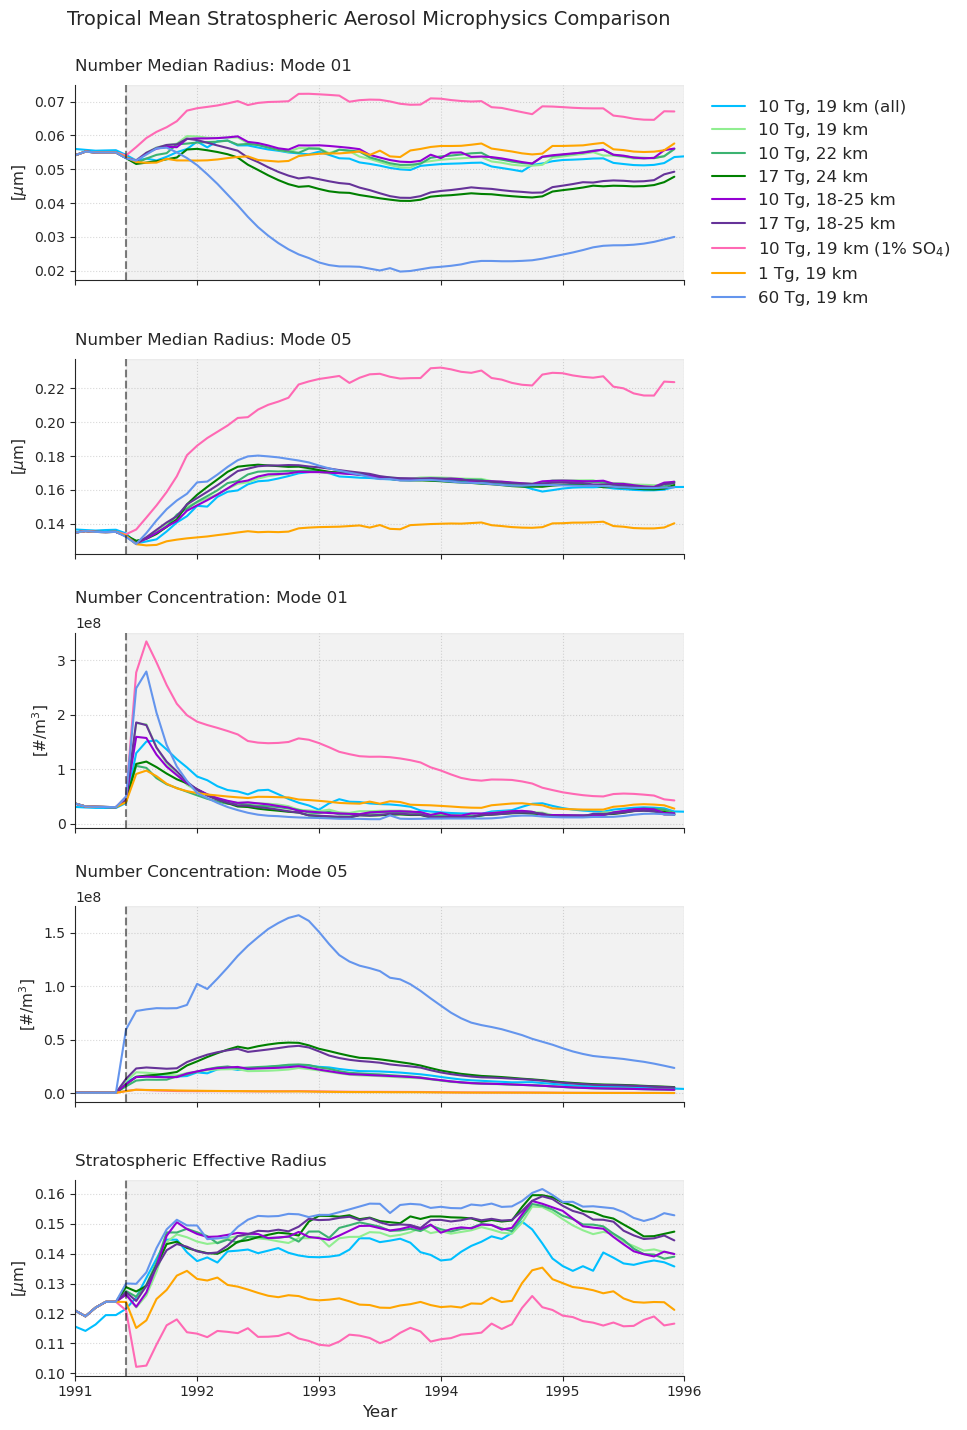

In [56]:
experiments = [SReff_trop, SReff_19_c_trop, SReff_22_trop, SReff_24_trop, SReff_1825_trop, SReff_1825_17tg_trop, SReff_1pr_trop, SReff_1tg_trop, SReff_60tg_trop]

sns.set_style("ticks")
fig, axs = plt.subplots(5, 1, figsize=(12, 15), sharex=True)

panel_info = [
    ("Number Median Radius: Mode 01", "NMR", "01", "[$\mu$m]", ds_nmr01),
    ("Number Median Radius: Mode 05", "NMR", "05", "[$\mu$m]", ds_nmr05),
    ("Number Concentration: Mode 01", "NCONC", "01", "[#/m$^3$]", ds_nconc01),
    ("Number Concentration: Mode 05", "NCONC", "05", "[#/m$^3$]", ds_nconc05),
    ("Stratospheric Effective Radius", "SREFF", "", "[$\mu$m]", experiments)
]

eruption_float = 1991 + (6-1)/12
end_float = 1996 

for i, (title, var_prefix, mode, unit, current_ds_list) in enumerate(panel_info):
    ax = axs[i]
    
    if var_prefix != "SREFF":
        for d, w, p, label, color in zip(current_ds_list, weights, levels, labels, colors):
            
            lev_vals = d.lev.values
            lev_diff = np.abs(np.gradient(lev_vals))
            wl = xr.DataArray(lev_diff, coords={'lev': d.lev}, dims=['lev'])
            
            var_name = f"{var_prefix}{mode}"
            raw_data = d[var_name].where(d["lev"] <= p)
            h_mean = raw_data.weighted(w).mean(dim=["lat", "lon"])
            
            data = h_mean.weighted(wl).mean(dim="lev")
            
            if var_prefix == "NMR":
                data = data * m_to_mym
                
            ax.plot(to_float(data), data, color=color, label=label)
            
    else:
        for e, label, color in zip(current_ds_list, labels, colors):
            x_vals = to_float(e)
            
            y_vals = e.values
            if np.nanmax(y_vals) < 1e-3: 
                y_vals = y_vals * 1e6
            
            ax.plot(x_vals, y_vals, color=color, label=label, linewidth=1.5)

    ax.set_title(title, loc='left', fontsize=12, pad=10)
    ax.set_ylabel(unit, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, color="gray", alpha=0.3, linestyle=":")
    
    ax.axvline(eruption_float, color='black', ls="--", alpha=0.5)
    ax.axvspan(eruption_float, end_float, color='gray', alpha=0.1, zorder=0)
    
    if i == 0:
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=12, frameon=False)

years = np.arange(1991, 1997)
axs[-1].set_xticks(years)
axs[-1].set_xticklabels([str(y) for y in years])
axs[-1].set_xlabel("Year", fontsize=12)
axs[-1].set_xlim(1991, 1996)

plt.suptitle("Tropical Mean Stratospheric Aerosol Microphysics Comparison", fontsize=14, x=0.06, 
             horizontalalignment='left')

plt.tight_layout(rect=[0, 0.03, 0.82, 0.98]) 
plt.subplots_adjust(hspace=0.4)

plt.show()

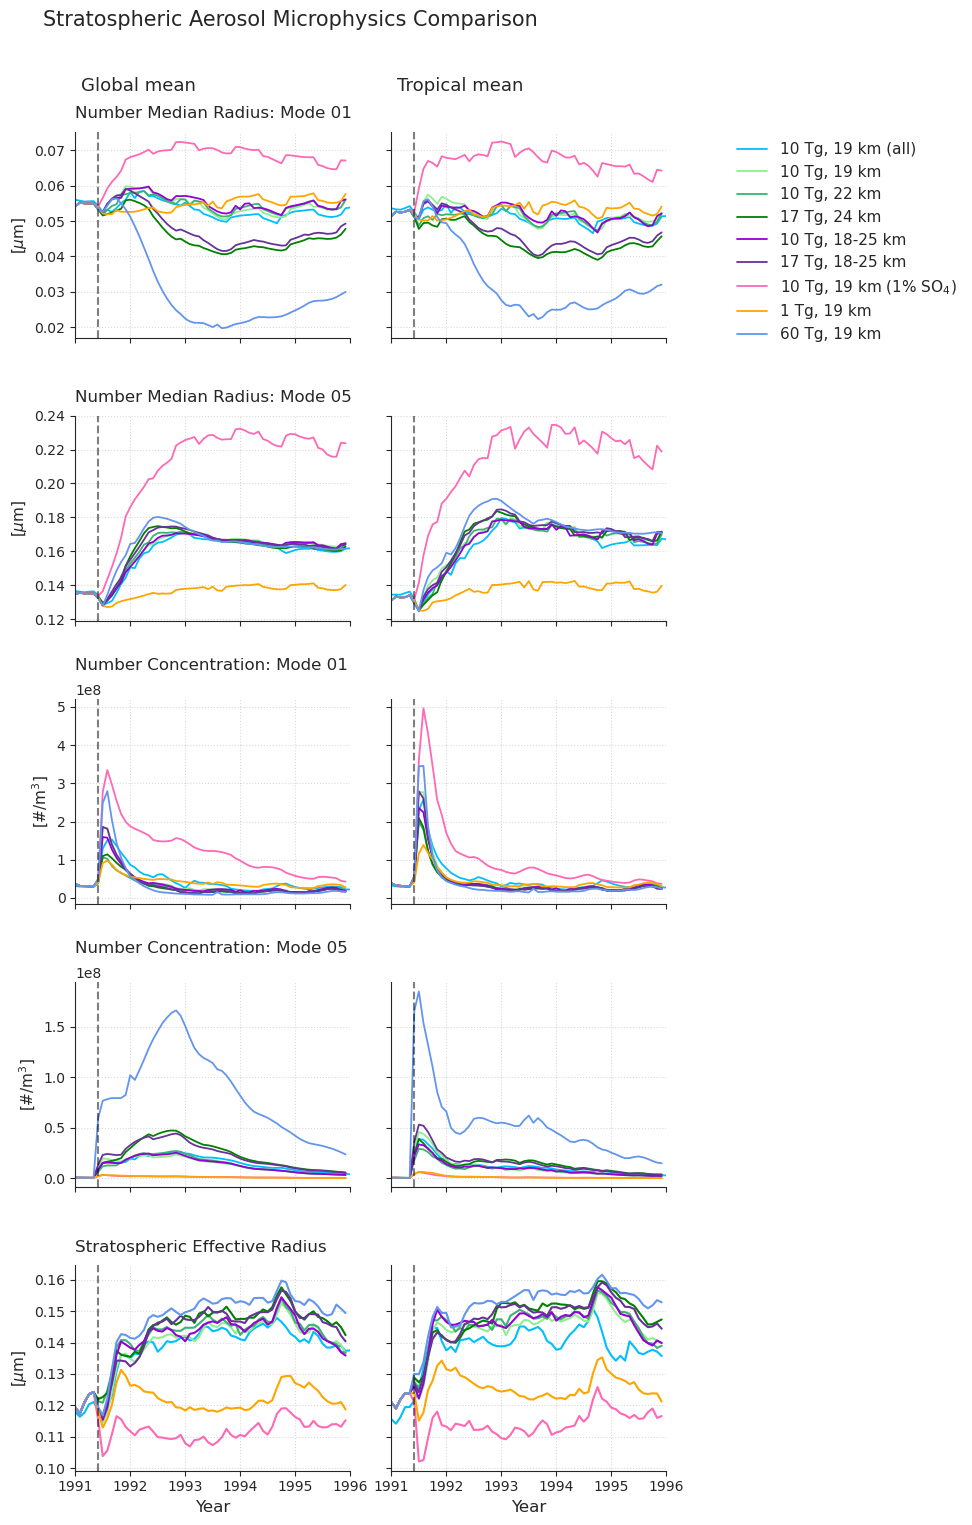

In [57]:
sns.set_style("ticks")

# Effective radius lists
experiments_global = [
    SReff,
    SReff_19_c,
    SReff_22,
    SReff_24,
    SReff_1825,
    SReff_1825_17tg,
    SReff_1pr,
    SReff_1tg,
    SReff_60tg
]

experiments_trop = [
    SReff_trop,
    SReff_19_c_trop,
    SReff_22_trop,
    SReff_24_trop,
    SReff_1825_trop,
    SReff_1825_17tg_trop,
    SReff_1pr_trop,
    SReff_1tg_trop,
    SReff_60tg_trop
]

panel_info_global = [
    ("Number Median Radius: Mode 01", "NMR", "01", "[$\\mu$m]", ds_nmr01),
    ("Number Median Radius: Mode 05", "NMR", "05", "[$\\mu$m]", ds_nmr05),
    ("Number Concentration: Mode 01", "NCONC", "01", "[#/m$^3$]", ds_nconc01),
    ("Number Concentration: Mode 05", "NCONC", "05", "[#/m$^3$]", ds_nconc05),
    ("Stratospheric Effective Radius", "SREFF", "", "[$\\mu$m]", experiments_global)
]

panel_info_trop = [
    ("Number Median Radius: Mode 01", "NMR", "01", "[$\\mu$m]", ds_nmr01),
    ("Number Median Radius: Mode 05", "NMR", "05", "[$\\mu$m]", ds_nmr05),
    ("Number Concentration: Mode 01", "NCONC", "01", "[#/m$^3$]", ds_nconc01),
    ("Number Concentration: Mode 05", "NCONC", "05", "[#/m$^3$]", ds_nconc05),
    ("Stratospheric Effective Radius", "SREFF", "", "[$\\mu$m]", experiments_trop)
]

eruption_float = 1991 + (6 - 1) / 12
end_float = 1996


def weighted_strat_mean(d, w, p, var_name, region="global"):
    raw_data = d[var_name].where(d["lev"] <= p)

    if region == "tropics":
        raw_data = raw_data.sel(lat=slice(-20, 20))
        w_use = w.sel(lat=slice(-20, 20))
    else:
        w_use = w

    h_mean = raw_data.weighted(w_use).mean(dim=["lat", "lon"])

    lev_vals = d.lev.values
    lev_diff = np.abs(np.gradient(lev_vals))
    wl = xr.DataArray(lev_diff, coords={"lev": d.lev}, dims=["lev"])

    data = h_mean.weighted(wl).mean(dim="lev")

    return data


fig, axs = plt.subplots(
    5, 2,
    figsize=(8, 16),
    sharex=True,
    sharey="row"
)

for col, (region_name, panel_info) in enumerate(
    zip(["Global mean", "Tropical mean"], [panel_info_global, panel_info_trop])
):
    for i, (title, var_prefix, mode, unit, current_ds_list) in enumerate(panel_info):
        ax = axs[i, col]

        if var_prefix != "SREFF":
            for d, w, p, label, color in zip(current_ds_list, weights, levels, labels, colors):
                var_name = f"{var_prefix}{mode}"

                data = weighted_strat_mean(
                    d,
                    w,
                    p,
                    var_name,
                    region="tropics" if col == 1 else "global"
                )

                if var_prefix == "NMR":
                    data = data * m_to_mym

                ax.plot(to_float(data), data, color=color, label=label, linewidth=1.3)

        else:
            for e, label, color in zip(current_ds_list, labels, colors):
                x_vals = to_float(e)

                y_vals = e.values
                if np.nanmax(y_vals) < 1e-3:
                    y_vals = y_vals * 1e6

                ax.plot(x_vals, y_vals, color=color, label=label, linewidth=1.5)

        if col == 0:
            ax.set_ylabel(unit, fontsize=11)
            ax.set_title(title, loc="left", fontsize=12, pad=10)
        

        if i == 0 and col == 0:
            ax.text(
                0.02, 1.18,
                "Global mean",
                transform=ax.transAxes,
                fontsize=13,
                ha="left",
                va="bottom"
            )

        if i == 0 and col == 1:
            ax.text(
                0.02, 1.18,
                "Tropical mean",
                transform=ax.transAxes,
                fontsize=13,
                ha="left",
                va="bottom"
            )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(True, color="gray", alpha=0.3, linestyle=":")

        ax.axvline(eruption_float, color="black", ls="--", alpha=0.5)

years = np.arange(1991, 1997)

for ax in axs[-1, :]:
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years])
    ax.set_xlabel("Year", fontsize=12)
    ax.set_xlim(1991, 1996)

handles, legend_labels = axs[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="center left",
    bbox_to_anchor=(0.91, 0.835),
    fontsize=11,
    frameon=False
)

fig.suptitle(
    "Stratospheric Aerosol Microphysics Comparison",
    fontsize=15,
    x=0.06,
    horizontalalignment="left"
)

plt.tight_layout(rect=[0, 0.03, 0.88, 0.97])
plt.subplots_adjust(hspace=0.38, wspace=0.15)

plt.show()

In [58]:
path_daily = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260120_pinatubo10Tg19_daily_branch/atm/hist"
ds_daily = xr.open_dataset(f'{path_daily}/NHIST_tropstratchem_f09_tn14_20260120_Pinatubo10Tg19_daily_branch.cam.h0.1991-06-02-00000.nc')

In [59]:
lat_daily = ds_daily["lat"]
weighted_lat_daily = np.cos(np.deg2rad(lat_daily))
tropopause_daily = ds_daily["TROP_P"].weighted(weighted_lat_daily).mean(dim=["lat", "lon"])
p_lev_daily = tropopause_daily * 0.01

lev_vals_daily = ds_daily.lev.values
lev_diff_daily = np.abs(np.gradient(lev_vals_daily))
wl_daily = xr.DataArray(lev_diff_daily, coords={'lev': ds_daily.lev}, dims=['lev'])


In [60]:
Reff_daily = ds_daily["REFF_AERO"].where(ds_daily["REFF_AERO"]["lev"] <= p_lev_daily)
Reff_daily = Reff_daily.sel(lat=slice(-20, 20))
Reff_h = Reff_daily.weighted(weighted_lat_daily).mean(dim=["lev", "lat", "lon"])
Reff_daily_final = Reff_h * cm_to_mym

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1205441/3761419597.py:18: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$m")


Text(0.5, 1.0, 'Tropical daily mean R$_{eff}$ ')

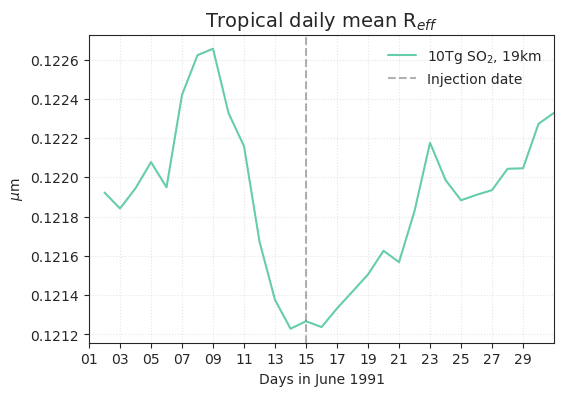

In [61]:
fig, ax = plt.subplots(figsize=(6, 4))
Reff_daily_final.plot(color="mediumaquamarine", label="10Tg SO$_2$, 19km")

eruption_date = cftime.DatetimeNoLeap(1991, 6, 15)
end_of_month = cftime.DatetimeNoLeap(1991, 7, 1)

ax.axvline(eruption_date, color='black', linestyle='--', alpha=0.3, label = "Injection date")

days = pd.date_range(start="1991-06-01", end="1991-06-30", freq="2D")
day_ticks = [cftime.DatetimeNoLeap(d.year, d.month, d.day) for d in days]

ax.set_xticks(day_ticks)
ax.set_xticklabels([d.strftime('%d') for d in days], rotation=0)
ax.set_xlim(cftime.DatetimeNoLeap(1991, 6, 1), cftime.DatetimeNoLeap(1991, 7, 1)) 
ax.grid(True, which='both', linestyle=':', alpha=0.5)
ax.legend(loc='upper right', frameon=False, fontsize=10)

plt.ylabel("$\mu$m")
plt.xlabel("Days in June 1991")
plt.title("Tropical daily mean R$_{eff}$ ", fontsize=14)

In [62]:
SReff_daily = compute_SReff_hybrid(ds_daily,  p_lev_lower=p_lev_daily) #, lat_range=(40,43), lon_range=(105, 106.5))

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1205441/437920407.py:12: SyntaxWarning: invalid escape sequence '\m'
  axes[i].set_ylabel("[$\mu$m]")


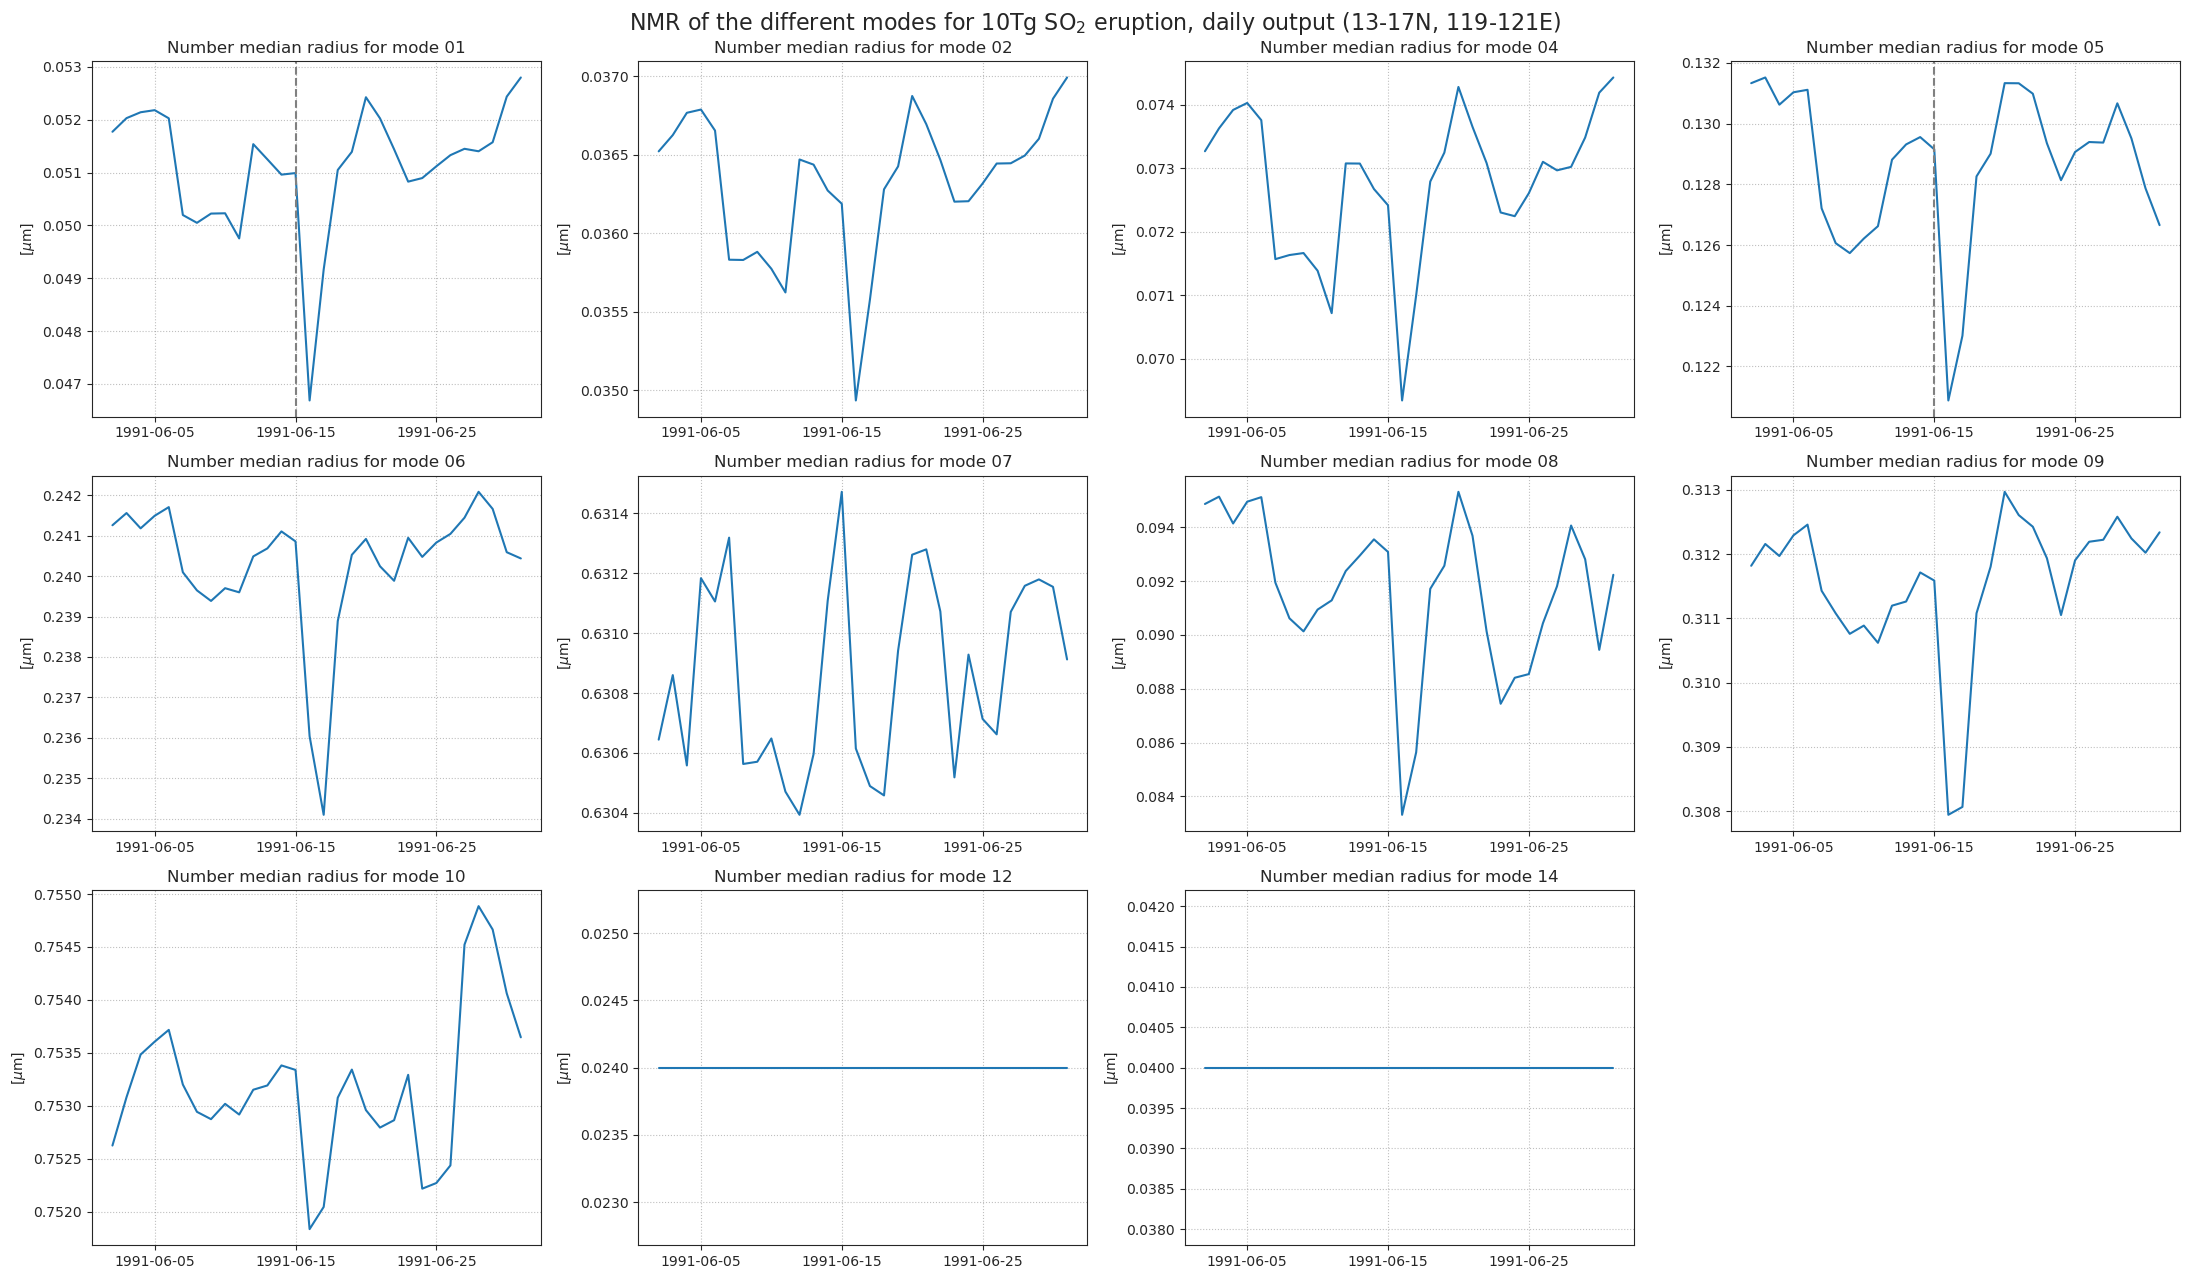

In [63]:
modes = ["01", "02", "04", "05", "06", "07", "08", "09", "10", "12", "14"]
m_to_mym = cm_to_mym*100
fig, axes = plt.subplots(3, 4, figsize=(22, 13), sharex=False, sharey=False)
axes = axes.flatten() 
for i, m in enumerate(modes):
    nmr = ds_daily[f"NMR{m}"].where(ds_daily[f"NMR{m}"]["lev"] <= p_lev_daily)
    nmr = nmr.sel(lat=slice(13,17))
    nmr = nmr.sel(lon=slice(119,121))
    nmr = nmr.weighted(weighted_lat_daily).mean(dim=["lat","lon","lev"])*m_to_mym
    axes[i].plot(nmr.time, nmr)
    axes[i].grid(color = "gray", alpha=0.5, linestyle=":")
    axes[i].set_ylabel("[$\mu$m]")
    axes[i].set_title(f"Number median radius for mode {m}")

    if m in ["01","05"]:
        t1line = cftime.DatetimeNoLeap(1991, 6, 15)
        axes[i].axvline(t1line, color="gray", linestyle="--")

for j in range(i+1, 3*4):
    fig.delaxes(axes[j])

plt.suptitle("NMR of the different modes for 10Tg SO$_2$ eruption, daily output (13-17N, 119-121E)", fontsize=16)
plt.tight_layout()
plt.show()

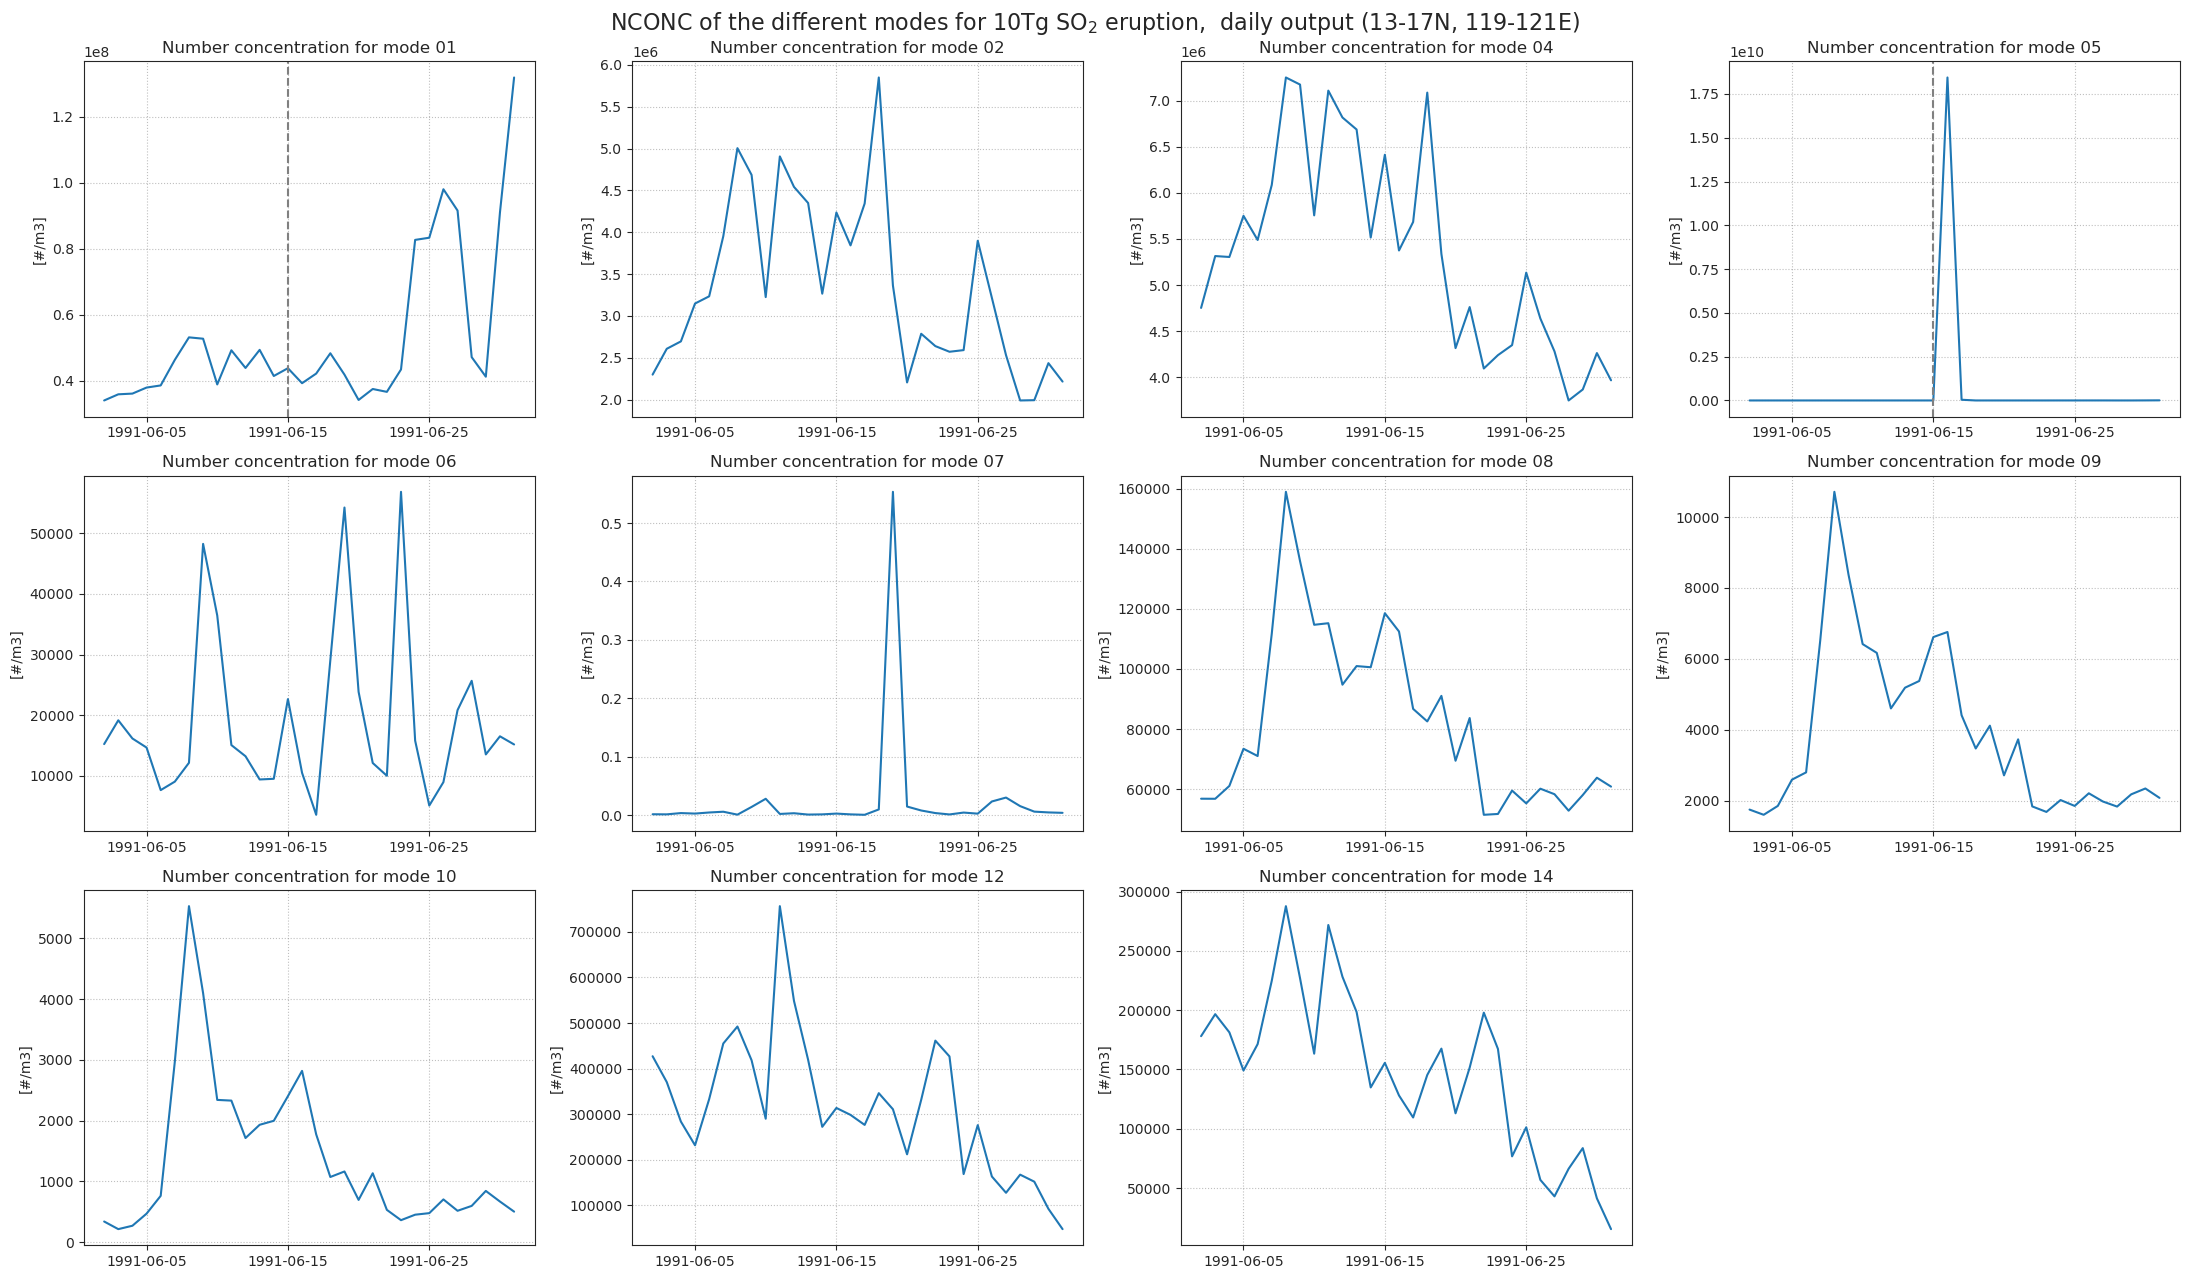

In [64]:
modes = ["01", "02", "04", "05", "06", "07", "08", "09", "10", "12", "14"]
m_to_mym = cm_to_mym*100
fig, axes = plt.subplots(3, 4, figsize=(22, 13), sharex=False, sharey=False)
axes = axes.flatten() 
for i, m in enumerate(modes):
    nconc = ds_daily[f"NCONC{m}"].where(ds_daily[f"NCONC{m}"]["lev"] <= p_lev_daily)
    nconc = nconc.sel(lat=slice(13,17))
    nconc = nconc.sel(lon=slice(119,121))
    nconc = nconc.weighted(weighted_lat_daily).mean(dim=["lat","lon","lev"])
    axes[i].plot(nconc.time, nconc)
    axes[i].grid(color = "gray", alpha=0.5, linestyle=":")
    axes[i].set_ylabel("[#/m3]")
    axes[i].set_title(f"Number concentration for mode {m}")

    if m in ["01","05"]:
        t1line = cftime.DatetimeNoLeap(1991, 6, 15)
        axes[i].axvline(t1line, color="gray", linestyle="--")

for j in range(i+1, 3*4):
    fig.delaxes(axes[j])

plt.suptitle("NCONC of the different modes for 10Tg SO$_2$ eruption,  daily output (13-17N, 119-121E)", fontsize=16)
plt.tight_layout()
plt.show()

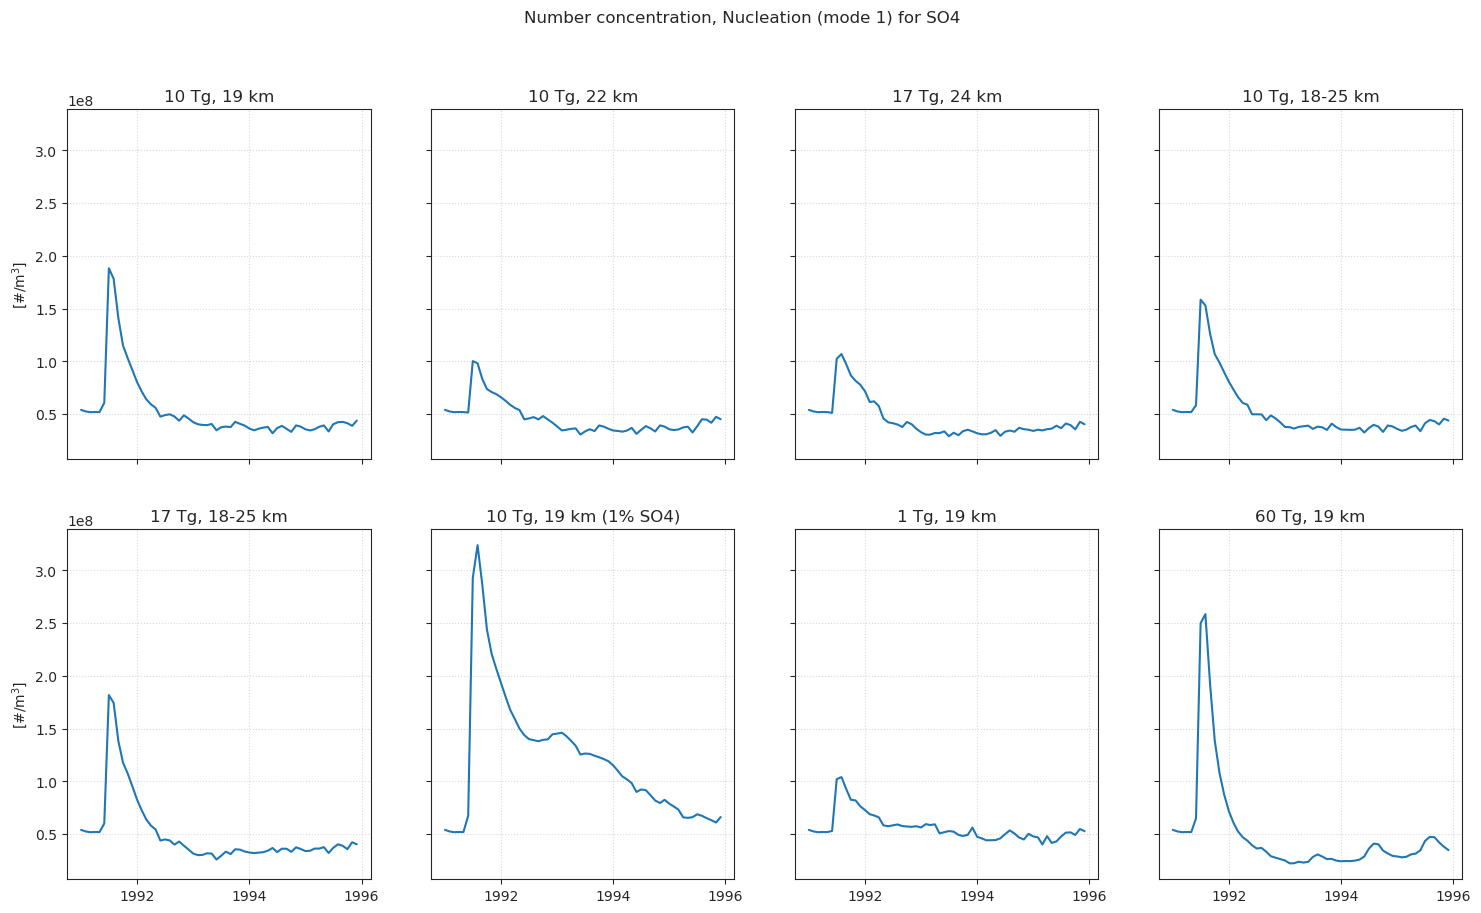

In [65]:
ds = [NCONC01_19_c, NCONC01_22, NCONC01_24, 
      NCONC01_1825, NCONC01_1825_17tg, NCONC01_1pr, 
      NCONC01_1tg, NCONC01_60tg]
levels = [p_lev_19_c, p_lev_22, p_lev_24, 
          p_lev_1825, p_lev_1825_17tg, p_lev_1pr,
          p_lev_1tg, p_lev_60tg]
weights = [weighted_lat_19_c, weighted_lat_22, weighted_lat_24,
           weighted_lat_1825, weighted_lat_1825_17tg, weighted_lat_1pr,
           weighted_lat_1tg, weighted_lat_60tg]

titles = ["10 Tg, 19 km", 
          "10 Tg, 22 km", 
          "17 Tg, 24 km", 
          "10 Tg, 18-25 km", 
          "17 Tg, 18-25 km", 
          "10 Tg, 19 km (1% SO4)", 
          "1 Tg, 19 km", 
          "60 Tg, 19 km"]

fig, axs = plt.subplots(2, 4, figsize=(18, 10), sharex=True, sharey=True)

for ax, current_ds, w, p, title in zip(axs.flat, ds, weights, levels, titles):
    lev_vals = current_ds.lev.values
    lev_diff = np.abs(np.gradient(lev_vals))
    wl = xr.DataArray(lev_diff, coords={'lev': current_ds.lev}, dims=['lev'])
    
    nconc_raw = current_ds["NCONC01"].where(current_ds["lev"] <= p)
    
    nconc_h = nconc_raw.weighted(w).mean(dim=["lat", "lon"])
    nconc_final = nconc_h.weighted(wl).mean(dim="lev")
    nconc_final.plot(ax=ax)
    
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("[#/m$^3$]" if ax in axs[:, 0] else "")
    ax.set_xlabel("") 
    ax.grid(color="gray", alpha=0.3, linestyle=":")

plt.suptitle("Number concentration, Nucleation (mode 1) for SO4")
plt.show()

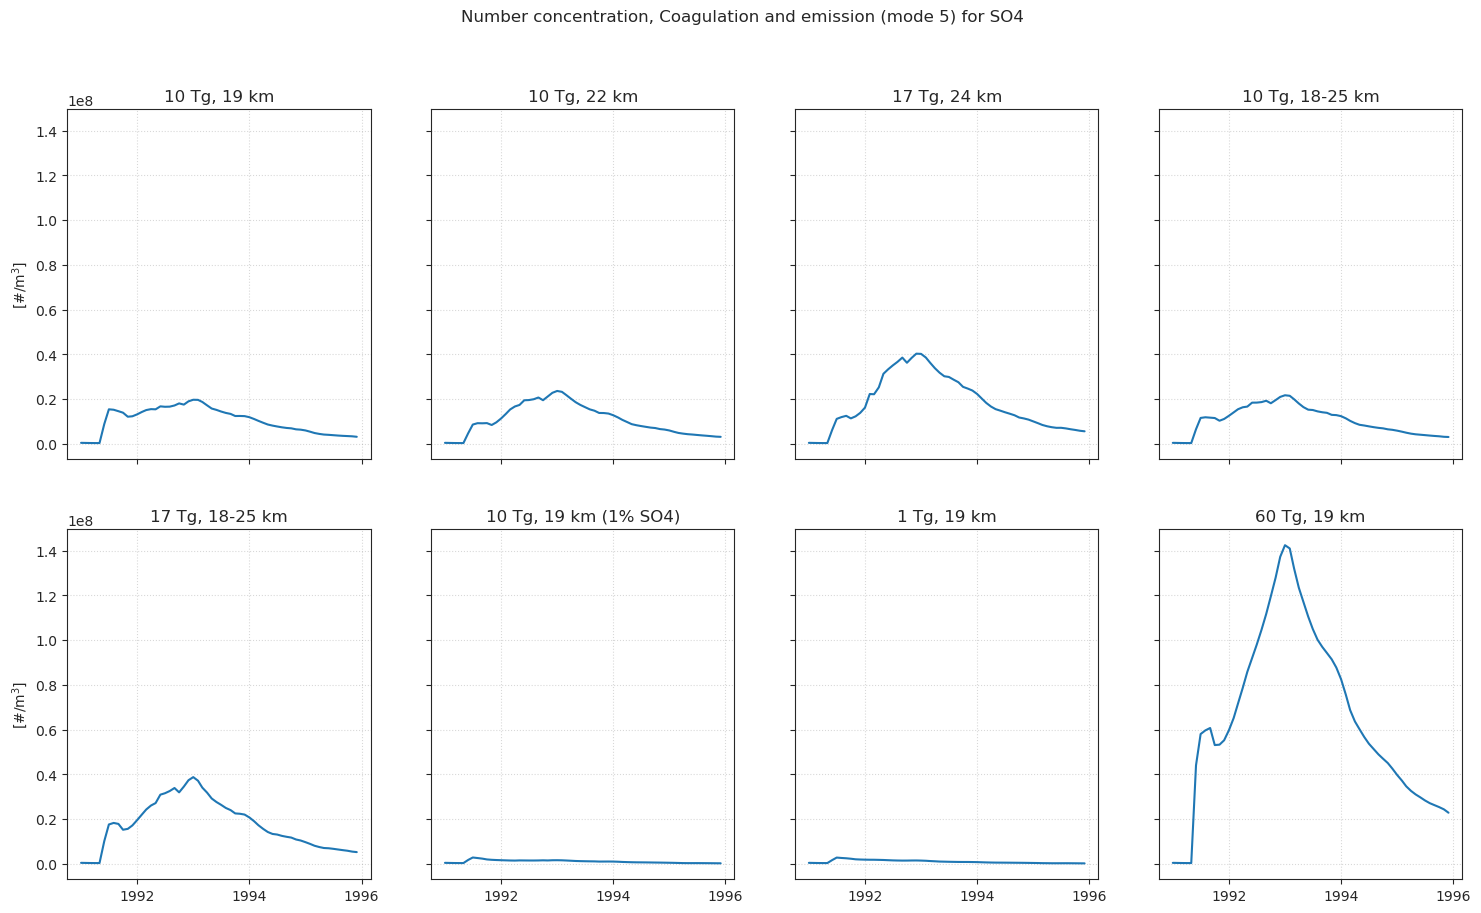

In [66]:
ds = [NCONC05_19_c, NCONC05_22, NCONC05_24, 
      NCONC05_1825, NCONC05_1825_17tg, NCONC05_1pr, 
      NCONC05_1tg, NCONC05_60tg]
levels = [p_lev_19_c, p_lev_22, p_lev_24, 
          p_lev_1825, p_lev_1825_17tg, p_lev_1pr,
          p_lev_1tg, p_lev_60tg]
weights = [weighted_lat_19_c, weighted_lat_22, weighted_lat_24,
           weighted_lat_1825, weighted_lat_1825_17tg, weighted_lat_1pr,
           weighted_lat_1tg, weighted_lat_60tg]

titles = ["10 Tg, 19 km", 
          "10 Tg, 22 km", 
          "17 Tg, 24 km", 
          "10 Tg, 18-25 km", 
          "17 Tg, 18-25 km", 
          "10 Tg, 19 km (1% SO4)", 
          "1 Tg, 19 km", 
          "60 Tg, 19 km"]

fig, axs = plt.subplots(2, 4, figsize=(18, 10), sharex=True, sharey=True)

for ax, current_ds, w, p, title in zip(axs.flat, ds, weights, levels, titles):
    lev_vals = current_ds.lev.values
    lev_diff = np.abs(np.gradient(lev_vals))
    wl = xr.DataArray(lev_diff, coords={'lev': current_ds.lev}, dims=['lev'])
    
    nconc_raw = current_ds["NCONC05"].where(current_ds["lev"] <= p)
    
    nconc_h = nconc_raw.weighted(w).mean(dim=["lat", "lon"])
    nconc_final = nconc_h.weighted(wl).mean(dim="lev")
    nconc_final.plot(ax=ax)
    
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("[#/m$^3$]" if ax in axs[:, 0] else "")
    ax.set_xlabel("") 
    ax.grid(color="gray", alpha=0.3, linestyle=":")

plt.suptitle("Number concentration, Coagulation and emission (mode 5) for SO4")
plt.show()

In [67]:
ds_daily["EC550SO4"]

<xarray.DataArray 'EC550SO4' (time: 30, lev: 32, lat: 192, lon: 288)> Size: 212MB
[53084160 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * time     (time) object 240B 1991-06-02 00:00:00 ... 1991-07-01 00:00:00
Attributes:
    mdims:         1
    units:         m-1
    long_name:     SO4 aerosol extinction coefficient
    cell_methods:  time: mean

Text(0.5, 1.0, 'Tropical stratospheric EC at 550nm of SO$_4$')

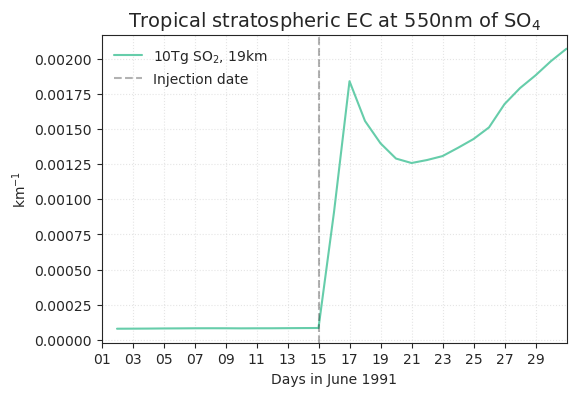

In [68]:
ec = ds_daily["EC550SO4"].where(ds_daily["EC550SO4"]["lev"]<= p_lev_daily)
ec = ec.sel(lat = slice(-20,20)).weighted(weighted_lat_daily).mean(dim=["lev", "lat", "lon"])
ec = ec*1000

fig, ax = plt.subplots(figsize=(6, 4))
ec.plot(color="mediumaquamarine", label="10Tg SO$_2$, 19km")

eruption_date = cftime.DatetimeNoLeap(1991, 6, 15)
end_of_month = cftime.DatetimeNoLeap(1991, 7, 1)

ax.axvline(eruption_date, color='black', linestyle='--', alpha=0.3, label = "Injection date")

days = pd.date_range(start="1991-06-01", end="1991-06-30", freq="2D")
day_ticks = [cftime.DatetimeNoLeap(d.year, d.month, d.day) for d in days]

ax.set_xticks(day_ticks)
ax.set_xticklabels([d.strftime('%d') for d in days], rotation=0)
ax.set_xlim(cftime.DatetimeNoLeap(1991, 6, 1), cftime.DatetimeNoLeap(1991, 7, 1)) 
ax.grid(True, which='both', linestyle=':', alpha=0.5)
ax.legend(loc='upper left', frameon=False, fontsize=10)

plt.ylabel("km$^{-1}$")
plt.xlabel("Days in June 1991")
plt.title("Tropical stratospheric EC at 550nm of SO$_4$", fontsize=14)


In [69]:
def get_weighted_extinction(ds, p_lev, lat_min=-90, lat_max=90):
    ds_area = ds.sel(lat=slice(lat_min, lat_max))
    
    weights_lat = np.cos(np.deg2rad(ds_area.lat))
    weights_lat.name = "weights"
    
    lev_vals = ds_area.lev.values
    lev_diff = np.abs(np.gradient(lev_vals))
    wl = xr.DataArray(lev_diff, coords={'lev': ds_area.lev}, dims=['lev'])
    
    ec = ds_area["EC550SO4"].where(ds_area["lev"] <= p_lev)
    ec_h = ec.weighted(weights_lat).mean(dim=["lat", "lon"])
    ec_final = ec_h.weighted(wl).mean(dim="lev")
    
    return ec_final

In [70]:
EC550SO4_19_c = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg19/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02/EC550SO4_h0_1991-1995.nc")
shifted_time_19_c = np.array([shift_one_month_back(t) for t in EC550SO4_19_c['time'].values])
EC550SO4_19_c = EC550SO4_19_c.assign_coords(time=shifted_time_19_c)
EC550SO4_22 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10Tg22/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01/EC550SO4_h0_1991-1995.nc")
shifted_time_22 = np.array([shift_one_month_back(t) for t in EC550SO4_22['time'].values])
EC550SO4_22 = EC550SO4_22.assign_coords(time=shifted_time_22)
EC550SO4_24 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg24/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01/EC550SO4_h0_1991-1995.nc")
shifted_time_24 = np.array([shift_one_month_back(t) for t in EC550SO4_24['time'].values])
EC550SO4_24 = EC550SO4_24.assign_coords(time=shifted_time_24)
EC550SO4_1825_17tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_17tg1825/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01/EC550SO4_h0_1991-1995.nc")
shifted_time_1825_17tg = np.array([shift_one_month_back(t) for t in EC550SO4_1825_17tg['time'].values])
EC550SO4_1825_17tg = EC550SO4_1825_17tg.assign_coords(time=shifted_time_1825_17tg)
EC550SO4_1825 = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg1825/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01/EC550SO4_h0_1991-1995.nc")
shifted_time_1825 = np.array([shift_one_month_back(t) for t in EC550SO4_1825['time'].values])
EC550SO4_1825 = EC550SO4_1825.assign_coords(time=shifted_time_1825)
EC550SO4_1tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_1tg19/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01/EC550SO4_h0_1991-1995.nc")
shifted_time_1tg = np.array([shift_one_month_back(t) for t in EC550SO4_1tg['time'].values])
EC550SO4_1tg = EC550SO4_1tg.assign_coords(time=shifted_time_1tg)
EC550SO4_1pr = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_10tg_1pr/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr/EC550SO4_h0_1991-1995.nc")
shifted_time_1pr = np.array([shift_one_month_back(t) for t in EC550SO4_1pr['time'].values])
EC550SO4_1pr = EC550SO4_1pr.assign_coords(time=shifted_time_1pr)
EC550SO4_60tg = xr.open_dataset("/nird/datapeak/NS1004K/elihho/output_60tg19/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19/EC550SO4_h0_1991-1995.nc")
shifted_time_60tg = np.array([shift_one_month_back(t) for t in EC550SO4_60tg['time'].values])
EC550SO4_60tg = EC550SO4_60tg.assign_coords(time=shifted_time_60tg)

#EC550SO4 is not available in long run, guess this is because aerocom s not on in that one. 

In [71]:
ec_19_c = get_weighted_extinction(EC550SO4_19_c, p_lev_19_c)
ec_22 = get_weighted_extinction(EC550SO4_22, p_lev_22)
ec_24 = get_weighted_extinction(EC550SO4_24, p_lev_24)
ec_1825= get_weighted_extinction(EC550SO4_1825, p_lev_1825)
ec_1825_17tg = get_weighted_extinction(EC550SO4_1825_17tg, p_lev_1825_17tg)
ec_1tg = get_weighted_extinction(EC550SO4_1tg, p_lev_1tg)
ec_1pr = get_weighted_extinction(EC550SO4_1pr, p_lev_1pr)
ec_60tg= get_weighted_extinction(EC550SO4_60tg, p_lev_60tg)

In [72]:
ec_19_c_trop = get_weighted_extinction(EC550SO4_19_c, p_lev_19_c_trop, lat_min=-20, lat_max=20)
ec_22_trop = get_weighted_extinction(EC550SO4_22, p_lev_22_trop, lat_min=-20, lat_max=20)
ec_24_trop = get_weighted_extinction(EC550SO4_24, p_lev_24_trop, lat_min=-20, lat_max=20)
ec_1825_trop = get_weighted_extinction(EC550SO4_1825, p_lev_1825_trop, lat_min=-20, lat_max=20)
ec_1825_17tg_trop = get_weighted_extinction(EC550SO4_1825_17tg, p_lev_1825_17tg_trop, lat_min=-20, lat_max=20)
ec_1tg_trop = get_weighted_extinction(EC550SO4_1tg, p_lev_1tg_trop, lat_min=-20, lat_max=20)
ec_1pr_trop = get_weighted_extinction(EC550SO4_1pr, p_lev_1pr_trop, lat_min=-20, lat_max=20)
ec_60tg_trop = get_weighted_extinction(EC550SO4_60tg, p_lev_60tg_trop, lat_min=-20, lat_max=20)

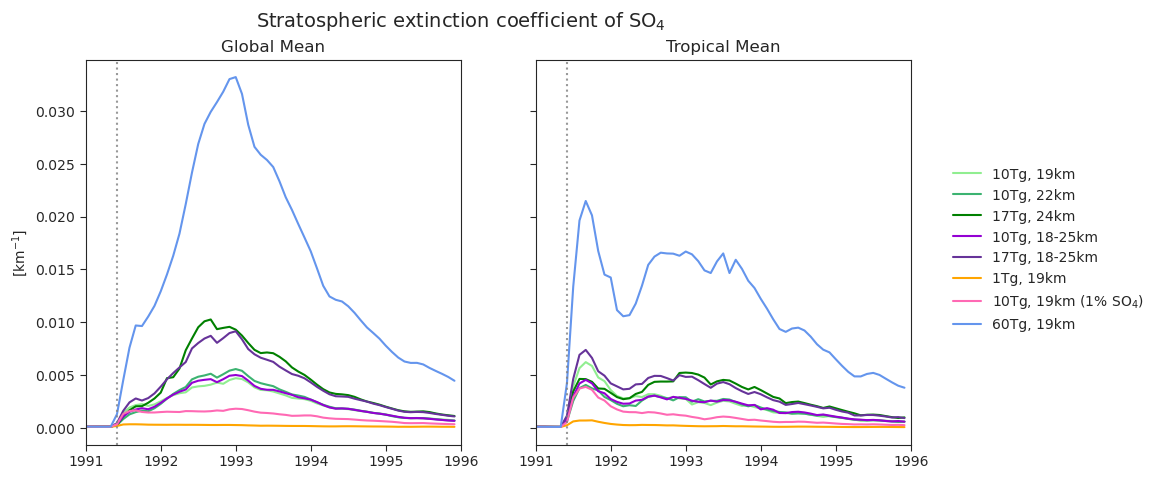

In [73]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(to_float(ec_19_c), ec_19_c* 1000, color="lightgreen", label="10Tg, 19km")
ax[0].plot(to_float(ec_22), ec_22* 1000, color="mediumseagreen", label="10Tg, 22km")
ax[0].plot(to_float(ec_24), ec_24* 1000, color="green", label="17Tg, 24km") 
ax[0].plot(to_float(ec_1825), ec_1825* 1000, color="darkviolet", label="10Tg, 18-25km")
ax[0].plot(to_float(ec_1825_17tg), ec_1825_17tg* 1000, color="rebeccapurple", label="17Tg, 18-25km")
ax[0].plot(to_float(ec_1tg), ec_1tg* 1000, color="orange", label="1Tg, 19km")
ax[0].plot(to_float(ec_1pr), ec_1pr* 1000, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[0].plot(to_float(ec_60tg), ec_60tg* 1000, color="cornflowerblue", label="60Tg, 19km")
ax[0].set_ylabel("[km$^{-1}$]")
ax[0].set_title("Global Mean", fontsize=12)

ax[1].plot(to_float(ec_19_c_trop), ec_19_c_trop* 1000, color="lightgreen", label="10Tg, 19km")
ax[1].plot(to_float(ec_22_trop), ec_22_trop* 1000, color="mediumseagreen", label="10Tg, 22km")
ax[1].plot(to_float(ec_24_trop), ec_24_trop* 1000, color="green", label="17Tg, 24km") 
ax[1].plot(to_float(ec_1825_trop), ec_1825_trop* 1000, color="darkviolet", label="10Tg, 18-25km")
ax[1].plot(to_float(ec_1825_17tg_trop), ec_1825_17tg_trop* 1000, color="rebeccapurple", label="17Tg, 18-25km")
ax[1].plot(to_float(ec_1tg_trop), ec_1tg_trop* 1000, color="orange", label="1Tg, 19km")
ax[1].plot(to_float(ec_1pr_trop), ec_1pr_trop* 1000, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[1].plot(to_float(ec_60tg_trop), ec_60tg_trop* 1000, color="cornflowerblue", label="60Tg, 19km")
ax[1].set_title("Tropical Mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12   

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)


handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Stratospheric extinction coefficient of SO$_4$", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

In [74]:
sageii_tropext = pd.read_csv(f"{path_obs}/sageii_tropical_ext.txt", delim_whitespace=True, header=0,  index_col=0)
start = pd.Timestamp("1991-01-01")
months_sageii = [int(c) for c in sageii_tropext.columns]
dates_sageii = [start + pd.DateOffset(months=m) for m in months_sageii]
sageii_tropext.columns = dates_sageii

levs = sageii_tropext.index.astype(float).values
times = sageii_tropext.columns

sage_da = xr.DataArray(
    sageii_tropext.to_numpy(), 
    dims=("lev", "time"),
    coords={"lev": levs, "time": times}
)

sage_strat = sage_da.where(sage_da.lev <= 100)
lev_diff = np.abs(np.gradient(levs))
wl_sage = xr.DataArray(lev_diff, coords={'lev': levs}, dims=['lev'])

sage_final = sage_strat.weighted(wl_sage).mean(dim="lev")

/tmp/ipykernel_1205441/2946798666.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sageii_tropext = pd.read_csv(f"{path_obs}/sageii_tropical_ext.txt", delim_whitespace=True, header=0,  index_col=0)


In [75]:
sageii_tropext_err = pd.read_csv(f"{path_obs}/sageii_tropical_ext_err.txt", delim_whitespace=True, header=0, index_col=0)
sageii_tropext_err.columns = dates_sageii 

sage_err_da = xr.DataArray(
    sageii_tropext_err.to_numpy(),
    dims=("lev", "time"),
    coords={"lev": levs, "time": times}
)

sage_err_strat = sage_err_da.where(sage_err_da.lev <= 100)
sage_err_final = sage_err_strat.weighted(wl_sage).mean(dim="lev")

/tmp/ipykernel_1205441/1219481658.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sageii_tropext_err = pd.read_csv(f"{path_obs}/sageii_tropical_ext_err.txt", delim_whitespace=True, header=0, index_col=0)


In [76]:
glossac_tropext = pd.read_csv(f"{path_obs}/glossac_tropical_ext.txt", delim_whitespace=True, header=0,  index_col=0)
start = pd.Timestamp("1991-01-01")
months_glossac = [int(c) for c in glossac_tropext.columns]
dates_glossac = [start + pd.DateOffset(months=m) for m in months_glossac]
glossac_tropext.columns = dates_glossac

levs = glossac_tropext.index.astype(float).values
times = glossac_tropext.columns

glossac_da = xr.DataArray(
    glossac_tropext.to_numpy(), 
    dims=("lev", "time"),
    coords={"lev": levs, "time": times}
)

glossac_strat = glossac_da.where(glossac_da.lev <= 100)
lev_diff = np.abs(np.gradient(levs))
wl_glossac = xr.DataArray(lev_diff, coords={'lev': levs}, dims=['lev'])

glossac_final = glossac_strat.weighted(wl_glossac).mean(dim="lev")

/tmp/ipykernel_1205441/3142931679.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  glossac_tropext = pd.read_csv(f"{path_obs}/glossac_tropical_ext.txt", delim_whitespace=True, header=0,  index_col=0)


In [77]:
glossac_tropext_err = pd.read_csv(f"{path_obs}/glossac_tropical_ext_err.txt", delim_whitespace=True, header=0, index_col=0)
glossac_tropext_err.columns = dates_glossac

glossac_err_da = xr.DataArray(
    glossac_tropext_err.to_numpy(),
    dims=("lev", "time"),
    coords={"lev": levs, "time": times}
)

glossac_err_strat = glossac_err_da.where(glossac_err_da.lev <= 100)
glossac_err_final = glossac_err_strat.weighted(wl_glossac).mean(dim="lev")

/tmp/ipykernel_1205441/341043329.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  glossac_tropext_err = pd.read_csv(f"{path_obs}/glossac_tropical_ext_err.txt", delim_whitespace=True, header=0, index_col=0)


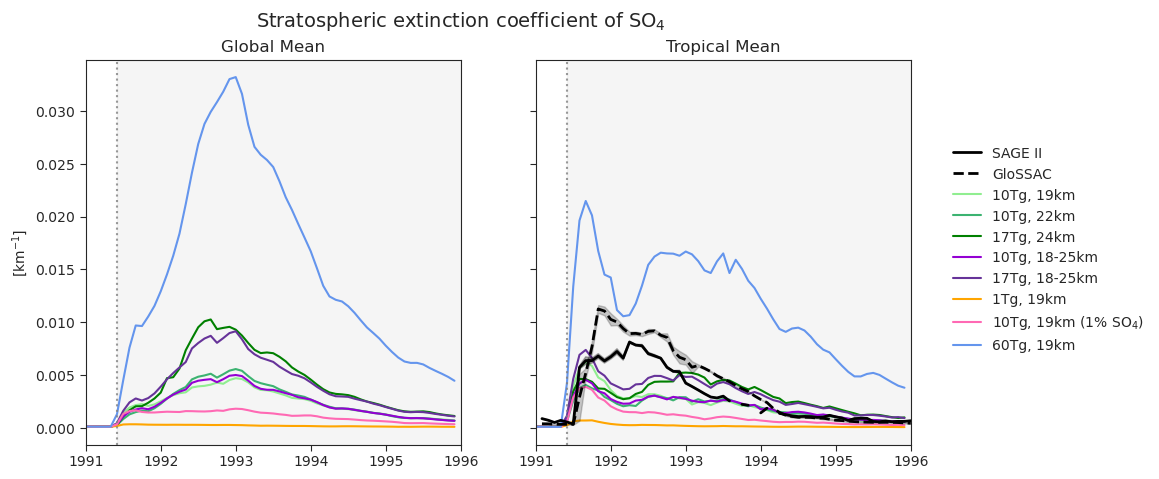

In [78]:
def to_float(x):
    if isinstance(x.time.values[0], np.datetime64):
        times = pd.DatetimeIndex(x.time.values)
        return [t.year + (t.month-1)/12 for t in times]
    else:
        return [t.year + (t.month-1)/12 for t in x.time.values]
    
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

ax[0].plot(to_float(ec_19_c), ec_19_c * 1000, color="lightgreen", label="10Tg, 19km")
ax[0].plot(to_float(ec_22), ec_22* 1000, color="mediumseagreen", label="10Tg, 22km")
ax[0].plot(to_float(ec_24), ec_24* 1000, color="green", label="17Tg, 24km") 
ax[0].plot(to_float(ec_1825), ec_1825* 1000, color="darkviolet", label="10Tg, 18-25km")
ax[0].plot(to_float(ec_1825_17tg), ec_1825_17tg* 1000, color="rebeccapurple", label="17Tg, 18-25km")
ax[0].plot(to_float(ec_1tg), ec_1tg* 1000, color="orange", label="1Tg, 19km")
ax[0].plot(to_float(ec_1pr), ec_1pr* 1000, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[0].plot(to_float(ec_60tg), ec_60tg* 1000, color="cornflowerblue", label="60Tg, 19km")
ax[0].set_ylabel("[km$^{-1}$]")
ax[0].set_title("Global Mean", fontsize=12)

sage_time_float = to_float(sage_final)
ax[1].plot(sage_time_float, sage_final, color="black", linewidth=2, label="SAGE II", zorder=10)
ax[1].fill_between(sage_time_float, 
                   sage_final - sage_err_final, 
                   sage_final + sage_err_final, 
                   color='black', alpha=0.3, zorder=9)
glossac_time_float = to_float(glossac_final)
ax[1].plot(glossac_time_float, glossac_final, color="black", linestyle="--", linewidth=2, label="GloSSAC", zorder=10)
ax[1].fill_between(glossac_time_float, 
                   glossac_final - glossac_err_final, 
                   glossac_final + glossac_err_final, 
                   color='black', alpha=0.2, zorder=9)
ax[1].plot(to_float(ec_19_c_trop), ec_19_c_trop* 1000, color="lightgreen", label="10Tg, 19km")
ax[1].plot(to_float(ec_22_trop), ec_22_trop* 1000, color="mediumseagreen", label="10Tg, 22km")
ax[1].plot(to_float(ec_24_trop), ec_24_trop* 1000, color="green", label="17Tg, 24km") 
ax[1].plot(to_float(ec_1825_trop), ec_1825_trop* 1000, color="darkviolet", label="10Tg, 18-25km")
ax[1].plot(to_float(ec_1825_17tg_trop), ec_1825_17tg_trop* 1000, color="rebeccapurple", label="17Tg, 18-25km")
ax[1].plot(to_float(ec_1tg_trop), ec_1tg_trop* 1000, color="orange", label="1Tg, 19km")
ax[1].plot(to_float(ec_1pr_trop), ec_1pr_trop* 1000, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[1].plot(to_float(ec_60tg_trop), ec_60tg_trop* 1000, color="cornflowerblue", label="60Tg, 19km")
ax[1].set_title("Tropical Mean", fontsize=12)

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)


handles, labels = ax[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Stratospheric extinction coefficient of SO$_4$", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

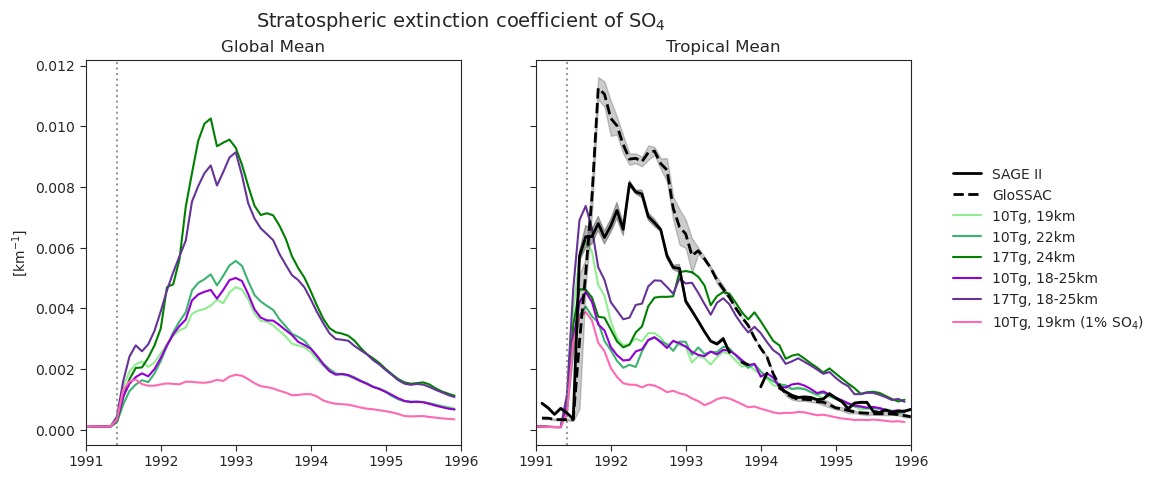

In [79]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

ax[0].plot(to_float(ec_19_c), ec_19_c * 1000, color="lightgreen", label="10Tg, 19km")
ax[0].plot(to_float(ec_22), ec_22* 1000, color="mediumseagreen", label="10Tg, 22km")
ax[0].plot(to_float(ec_24), ec_24* 1000, color="green", label="17Tg, 24km") 
ax[0].plot(to_float(ec_1825), ec_1825* 1000, color="darkviolet", label="10Tg, 18-25km")
ax[0].plot(to_float(ec_1825_17tg), ec_1825_17tg* 1000, color="rebeccapurple", label="17Tg, 18-25km")
ax[0].plot(to_float(ec_1pr), ec_1pr* 1000, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[0].set_ylabel("[km$^{-1}$]")
ax[0].set_title("Global Mean", fontsize=12)

sage_time_float = to_float(sage_final)
ax[1].plot(sage_time_float, sage_final, color="black", linewidth=2, label="SAGE II", zorder=10)
ax[1].fill_between(sage_time_float, 
                   sage_final - sage_err_final, 
                   sage_final + sage_err_final, 
                   color='black', alpha=0.3, zorder=9)
glossac_time_float = to_float(glossac_final)
ax[1].plot(glossac_time_float, glossac_final, color="black", linestyle="--", linewidth=2, label="GloSSAC", zorder=10)
ax[1].fill_between(glossac_time_float, 
                   glossac_final - glossac_err_final, 
                   glossac_final + glossac_err_final, 
                   color='black', alpha=0.2, zorder=9)
ax[1].plot(to_float(ec_19_c_trop), ec_19_c_trop* 1000, color="lightgreen", label="10Tg, 19km")
ax[1].plot(to_float(ec_22_trop), ec_22_trop* 1000, color="mediumseagreen", label="10Tg, 22km")
ax[1].plot(to_float(ec_24_trop), ec_24_trop* 1000, color="green", label="17Tg, 24km") 
ax[1].plot(to_float(ec_1825_trop), ec_1825_trop* 1000, color="darkviolet", label="10Tg, 18-25km")
ax[1].plot(to_float(ec_1825_17tg_trop), ec_1825_17tg_trop* 1000, color="rebeccapurple", label="17Tg, 18-25km")
ax[1].plot(to_float(ec_1pr_trop), ec_1pr_trop* 1000, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[1].set_title("Tropical Mean", fontsize=12)

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)


handles, labels = ax[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Stratospheric extinction coefficient of SO$_4$", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

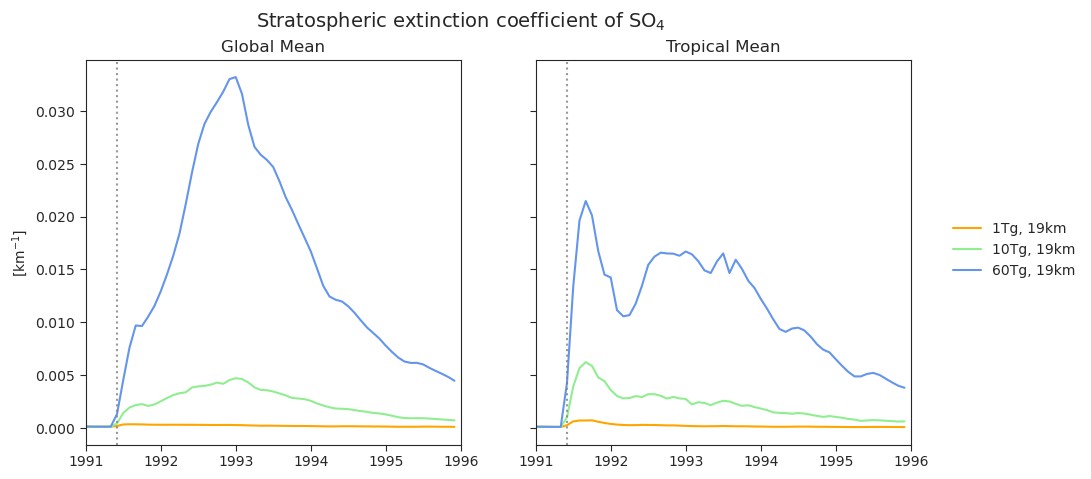

In [80]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(to_float(ec_1tg), ec_1tg* 1000, color="orange", label="1Tg, 19km")
ax[0].plot(to_float(ec_19_c), ec_19_c* 1000, color="lightgreen", label="10Tg, 19km")
ax[0].plot(to_float(ec_60tg), ec_60tg* 1000, color="cornflowerblue", label="60Tg, 19km")
ax[0].set_ylabel("[km$^{-1}$]")
ax[0].set_title("Global Mean", fontsize=12)

ax[1].plot(to_float(ec_1tg_trop), ec_1tg_trop* 1000, color="orange", label="1Tg, 19km")
ax[1].plot(to_float(ec_19_c_trop), ec_19_c_trop* 1000, color="lightgreen", label="10Tg, 19km")
ax[1].plot(to_float(ec_60tg_trop), ec_60tg_trop* 1000, color="cornflowerblue", label="60Tg, 19km")
ax[1].set_title("Tropical Mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12   

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)


handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Stratospheric extinction coefficient of SO$_4$", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()